In [25]:
pathout = ".."

import sys
sys.path.append(pathout)
from TheModel_reducedForSymmSIRS import *

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# ---------- SIRS Model of 2 Cooperative Diseases ----------

In [26]:
epsi=.005
C=15
alpha=.08
tmax=12*360
mmax = 0 # automatic because in this notebook we use reduced model wo feedback
s=0

p = {
        'y0': [1-epsi, epsi/2, epsi/2, 0, epsi/2, 0],
        'beta': C*alpha, 
        'alpha': alpha,
        'gamma': .1,
        'nu': .01,
        'tmin': 0,
        'tmax': tmax,
        'stepsize': 0.1,      
        'maxstep': 10,
        'direction': True,
        's': s,              # seasonality amplitude
        'w': 2*np.pi/360,        # seasonality frequency (repeats after every 360days)
        'seasonalshift': 0,
    }

## Phasetransitions $\alpha$ vs $R_\infty$ (without seasonality)

In [27]:
thresh = 220 # as used for heatmap                        # 120 # as checked below
p['s'] = 0
InInfComp = 'A and B'

In [28]:
years = 12 # how long to reach steady state

def Plot_Alpha_Rinf(alpha, C, epsi, p, tmax=years*360, COL='Auto', InInfComp='A and B', epsi_labeling='linestyle'):
    N = len(alpha)
    R_inf = np.empty(N)
    p['tmax'] = tmax

    LS = [':','-.','--','-']
    
    for k in range(len(epsi)):
        SetInCondredSIRS(epsi[k], p, InInfComp)
        for j in range(len(C)):
            for i in range(N):
                p['beta'] = C[j]*alpha[i]
                p['alpha'] = alpha[i]
                m = model(**p)
                times, Data = m.run()
                S = Data[0]
                R_inf[i] = 1-S[-1]

            # C values labeling: color
            if(COL=='Auto'):
                cmap = mpl.colormaps['tab10']
                color = cmap((j+.5)/10)
            else: color = COL

            # epsi values labeling
            if(epsi_labeling=='transparency'):
                alph = (k+1)/len(epsi)
                if(j==0 and len(epsi)>1): 
                    if(len(C)>1): plt.plot([-1,-2], [-1,-2], label=rf'$\epsilon=${epsi[k]}',c='k',alpha=alph)
                    else: plt.plot([-1,-2], [-1,-2], label=rf'$\epsilon=${epsi[k]}',c=color,alpha=alph)
                plt.plot(alpha, R_inf,c=color,alpha=alph)
            elif('linestyle'):
                if(j==0 and len(epsi)>1): 
                    if(len(C)>1): plt.plot([-1,-2], [-1,-2], label=rf'$\epsilon=${epsi[k]}',c='k',ls=LS[k%len(LS)])
                    else: plt.plot([-1,-2], [-1,-2], label=rf'$\epsilon=${epsi[k]}',c=color,ls=LS[k%len(LS)])
                plt.plot(alpha, R_inf,c=color,ls=LS[k%len(LS)])

            # C values labeling: label
            if(k==len(epsi)-1 and len(C)>1): plt.plot([-1,-2], [-1,-2], label=rf'$C=${C[j]}',c=color)

            if(len(C)==1): plt.title(rf'$C=${C[j]}')
            if(len(epsi)==1): plt.title(rf'$\epsilon=${epsi[k]}')
            
            #if((k*len(C)+j)%int((len(epsi)*len(C))/10)==0): print(int((k*len(C)+j)*10/(len(epsi)*len(C))+1),'/10')
            if(len(C)>len(epsi)): 
                if(k==0): print(j+1,'/',len(C))
        if(len(epsi)>len(C)): print(k+1,'/',len(epsi))
    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$R_\infty=1-S_\infty$')
    plt.xlim(np.min(alpha),np.max(alpha))
    plt.ylim(-0.01,1.01)
    #plt.title(f'With initial fraction of infected $\epsilon=${epsi}')
    return 1

def Plot_Deriv_Alpha_Rinf(alpha, C, epsi, p, tmax=years*360, InInfComp='A and B'):
    N = len(alpha)
    dR_inf = np.empty(N-1)
    dalpha = (max(alpha)-min(alpha))/N
    p['tmax'] = tmax
    
    DerivativeMaxima = np.empty((len(epsi),len(C)))
    
    for k in range(len(epsi)):
        SetInCondredSIRS(epsi[k], p, InInfComp)
        for j in range(len(C)):
            for i in range(N-1):
                p['beta'] = C[j]*alpha[i]
                p['alpha'] = alpha[i]
                m = model(**p)
                times, Data = m.run()
                S = Data[0]
                R_inf = 1-S[-1]
                if(i>0):
                    dR_inf[i] = (R_inf-R_inf_prev)/dalpha
                R_inf_prev = R_inf
            DerivativeMaxima[k,j] = np.max(dR_inf)
            plt.plot(alpha[1:], dR_inf, label=rf'$\epsilon=${epsi[k]}, $C=${C[j]}')
            #if((k*len(C)+j)%int((len(epsi)*len(C))/10)==0): print(int((k*len(C)+j)*10/(len(epsi)*len(C))+1),'/10')
            if(len(epsi)>len(C)): print(k+1,'/',len(epsi))
            if(len(C)>len(epsi)): print(j+1,'/',len(C))
    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$\partial_\alpha R_\infty=-\partial_\alpha S_\infty$')
    #plt.title(f'With initial fraction of infected $\epsilon=${epsi}')
    return DerivativeMaxima

def Plot_C_alphacrit(C, epsi, p, tmax=years*360, InInfComp='A and B'):
    p['tmax'] = tmax
    N = 1000
    alpha = np.linspace(0,.12,N)
    dalpha = (max(alpha)-min(alpha))/N
    alpha_crit = np.empty(len(C))
    SetInCondredSIRS(epsi, p, InInfComp)

    idx_lastPT = 0
    for j in range(len(C)):
        for i in range(N-idx_lastPT):
            p['beta'] = C[j]*alpha[-1-i-idx_lastPT]
            p['alpha'] = alpha[-1-i-idx_lastPT]
            m = model(**p)
            times, Data = m.run()
            S = Data[0]
            R_inf = 1-S[-1]
            if(i==N-idx_lastPT-1): alpha_crit[j] = 0 #No Phasetransition
            if(i>0):
                if(np.abs(R_inf-R_inf_prev)/dalpha > thresh):
                    alpha_crit[j] = alpha[-1-i-idx_lastPT]
                    idx_lastPT += i
                    break
            R_inf_prev = R_inf
            
        print(j+1,'/',len(C))

    print(alpha_crit)
    plt.scatter(C, alpha_crit)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$C$')
    plt.ylabel(r'$\alpha_{\rm crit}$')
    plt.title(f'With initial fraction of infected $\epsilon=${epsi}')
    plt.legend()
    plt.grid()
    plt.show()

##### Experiment

1 / 9
2 / 9
3 / 9
4 / 9
5 / 9
6 / 9
7 / 9
8 / 9
9 / 9


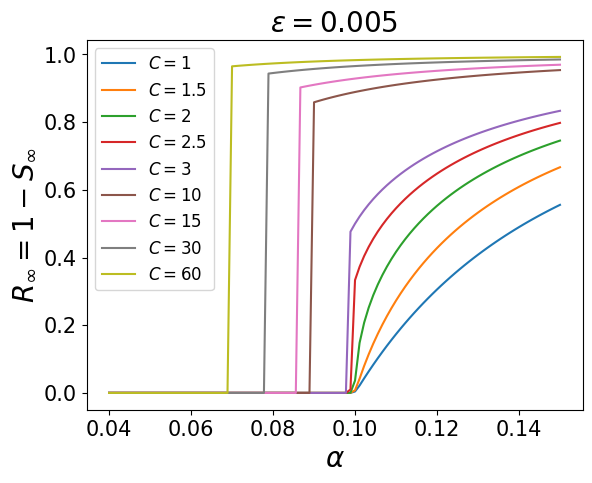

In [ ]:
C = [1,1.5,2,2.5,3,10,15,30,60]
alpha = np.linspace(.04,.15,100)
epsi = [.005]

Plot_Alpha_Rinf(alpha, C, epsi, p)
plt.legend()
plt.show()

1 / 8
2 / 8
3 / 8
4 / 8
5 / 8
6 / 8
7 / 8
8 / 8


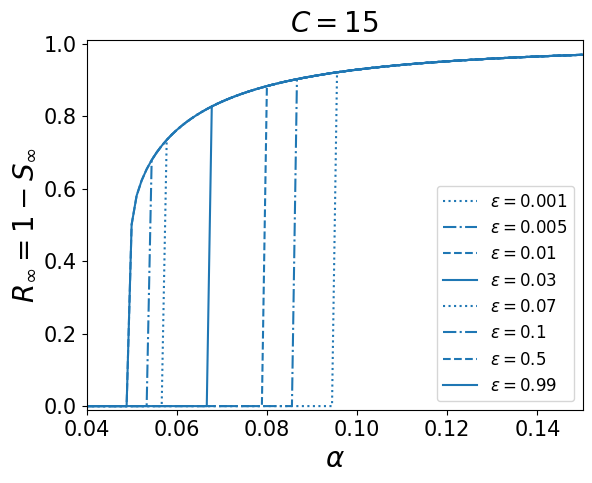

In [ ]:
C = [15]
alpha = np.linspace(.04,.15,100)
epsi = [.001,.005,.01,.03,.07,.1,.5,.99]

Plot_Alpha_Rinf(alpha, C, epsi, p)
plt.legend()
plt.show()

1 / 4
2 / 4
3 / 4
4 / 4


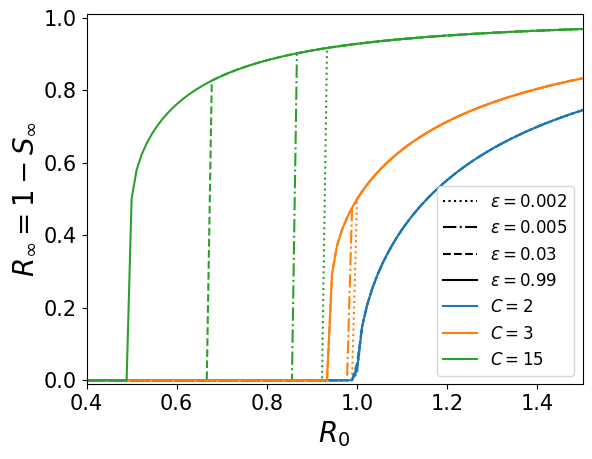

In [239]:
C = [2,3,15]
alpha = np.linspace(.04,.15,100)
epsi = [.002,.005,.03,.99]

# plt.rcParams['font.size'] = 25
# plt.rcParams['xtick.labelsize'] = 20
# plt.rcParams['ytick.labelsize'] = 20
# plt.rcParams['legend.fontsize'] = 15
# plt.rcParams['axes.titlesize'] = 25


Plot_Alpha_Rinf(alpha, C, epsi, p, InInfComp='A and B')
plt.legend(loc='lower right')
ChangeXTicksFromAlphaToR0()
plt.xlim(np.min(alpha), np.max(alpha))
plt.savefig('img/SIRS_PT_Rinfty_vs_alpha_fordiff_epsi_C.pdf', bbox_inches='tight')
#plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

<font color = 'red'> $C$ sets the shape of the endemic part of the PT and shifts $\alpha_{\rm crit}$, $\epsilon$ only shifts $\alpha_{\rm crit}$

1 / 5
2 / 5
3 / 5
4 / 5
5 / 5


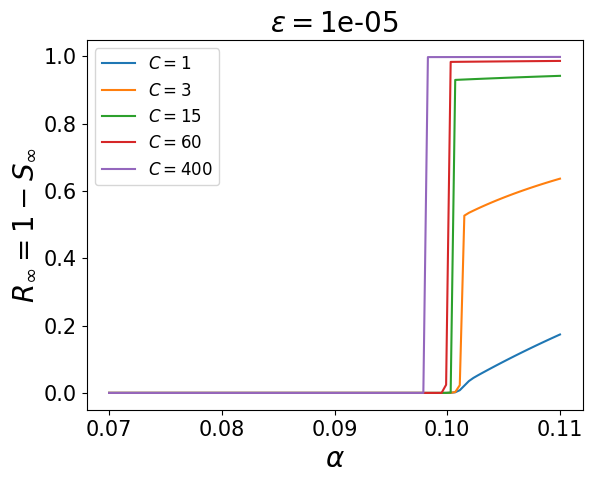

In [ ]:
C = [1,3,15,60,400]
alpha = np.linspace(.07,.11,100)
epsi = [1e-5]

Plot_Alpha_Rinf(alpha, C, epsi, p)
plt.legend()
plt.show()

1 / 9
2 / 9
3 / 9
4 / 9
5 / 9
6 / 9
7 / 9
8 / 9
9 / 9


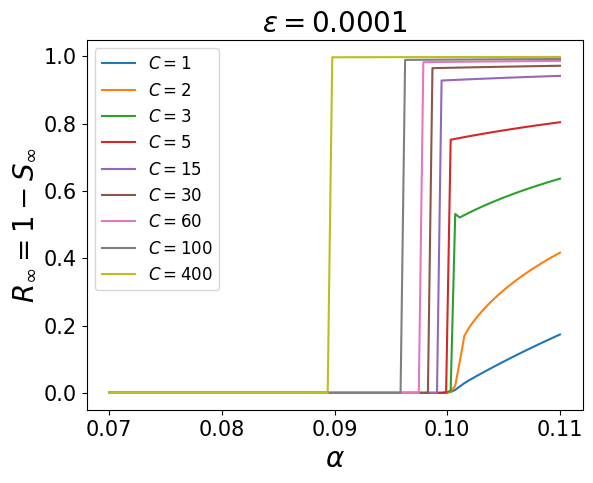

In [ ]:
C = [1,2,3,5,15,30,60,100,400]
alpha = np.linspace(.07,.11,100)
epsi = [1e-4]

Plot_Alpha_Rinf(alpha, C, epsi, p)
plt.legend()
plt.show()

In [186]:
alpha = np.linspace(.01,.12,100)
C = np.logspace(-1,2,100)
epsi = np.logspace(-4,0,100)

C_val = 15
epsi_val = .005

In [ ]:
Rinf_fixedepsi = Simul_Rinf_for_C_alpha(alpha, C, epsi_val, p)
np.save(f'Data/DataSIRS_Rinf_for_C_alpha_atepsi={epsi_val}.npy', Rinf_fixedepsi)

1 /10
2 /10
3 /10
4 /10
5 /10
6 /10
7 /10
8 /10
9 /10
10 /10


In [ ]:
Rinf_fixedC = Simul_Rinf_for_epsi_alpha(alpha, C_val, epsi, p)
np.save(f'Data/DataSIRS_Rinf_for_epsi_alpha_atC={C_val}.npy', Rinf_fixedC)

1 /10
2 /10
3 /10
4 /10
5 /10
6 /10
7 /10
8 /10
9 /10
10 /10


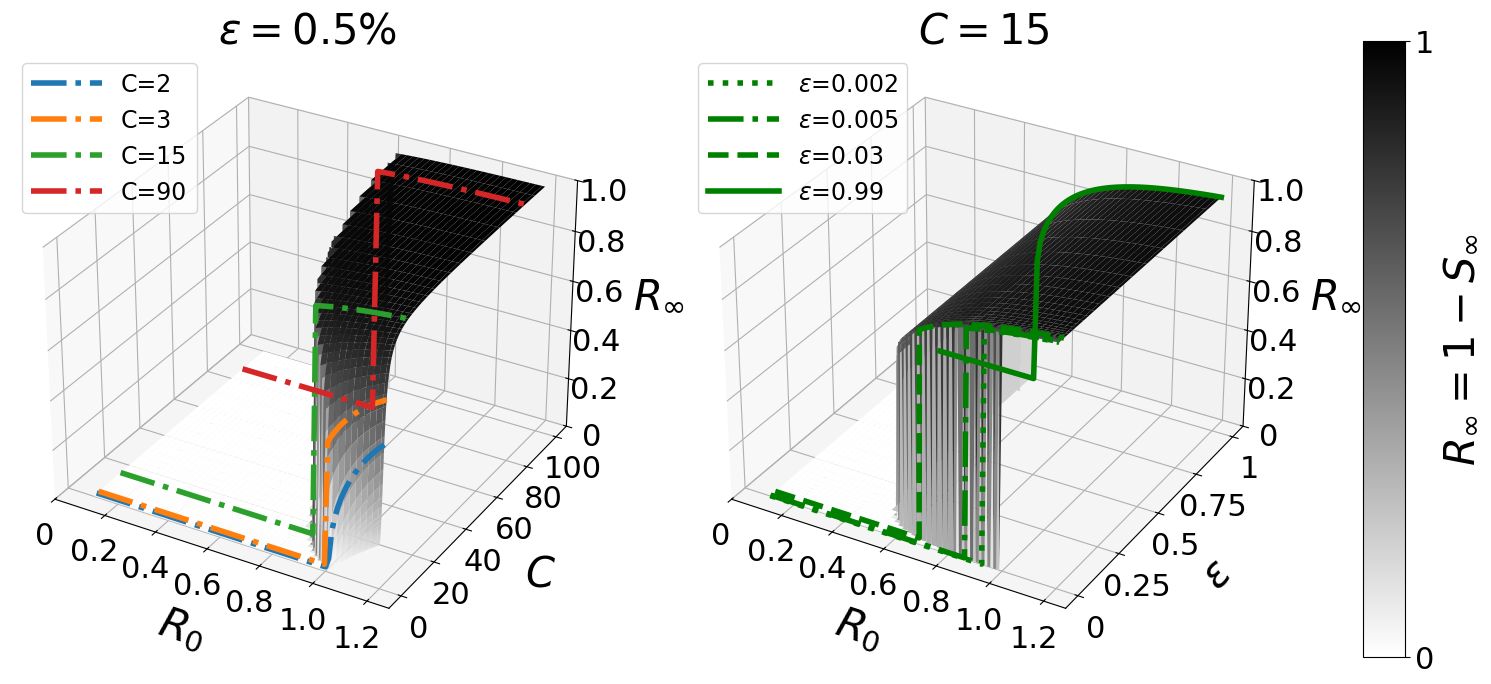

In [207]:
Rinf_fixedepsi = np.load(f'Data/DataSIRS_Rinf_for_C_alpha_atepsi={epsi_val}.npy')
Rinf_fixedC = np.load(f'Data/DataSIRS_Rinf_for_epsi_alpha_atC={C_val}.npy')

cmap = mpl.colormaps['tab10']
LS = [':','-.','--','-']
CMAP = 'binary' #'cool'
LP = 18

C_emphValues = [2,3,15,90]
epsi_emphValues = [.002,.005,.03,.99] # [.001,.005,.025,.8]

C_idces = [np.argmin(np.abs(C - C_value)) for C_value in C_emphValues]
epsi_idces = [np.argmin(np.abs(epsi - epsi_value)) for epsi_value in epsi_emphValues]

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 22
plt.rcParams['ytick.labelsize'] = 22
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['axes.titlesize'] = 30

fig = plt.figure(figsize=(18,8))

# Create a GridSpec layout
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.07])  
ax1 = fig.add_subplot(gs[0, 0], projection='3d')  
ax2 = fig.add_subplot(gs[0, 1], projection='3d')  
cbar_ax = fig.add_subplot(gs[0, 2]) 


#ax1 = fig.add_subplot(121, projection='3d')
alpha_mesh, C_mesh = np.meshgrid(alpha, C)
surf1 = ax1.plot_surface(alpha_mesh, C_mesh, Rinf_fixedepsi.T, cmap=CMAP, vmin=0, vmax=1)
for idx_idx, idx in enumerate(C_idces): 
    color = cmap((idx_idx+.5)/10)
    ax1.plot(alpha, np.full_like(alpha, C[idx]), Rinf_fixedepsi[:, idx], c=color, label=f'C={C_emphValues[idx_idx]}', zorder=5, ls='-.', lw=4)
ax1.set_title(r'$\epsilon=0.5\%$')
ax1.set_xlabel(r'$R_0$', labelpad=LP)
ax1.set_ylabel(r'$C$', labelpad=LP)
ax1.set_zlabel(r'$R_\infty$', labelpad=LP)
ax1.set_zlim(0,1)
ax1.zaxis.set_rotate_label(False)
ax1.set_xticks([0,.02,.04,.06,.08,.1,.12],labels=['0','0.2','0.4','0.6','0.8','1.0','1.2'])
ax1.set_zticks([0,.2,.4,.6,.8,1],labels=['0','0.2','0.4','0.6','0.8','1.0'])
ax1.legend(loc='upper left', handlelength=3, fontsize=17)

#ax2 = fig.add_subplot(122, projection='3d')
alpha_mesh, epsi_mesh = np.meshgrid(alpha, epsi)
surf2 = ax2.plot_surface(alpha_mesh, epsi_mesh, Rinf_fixedC.T, cmap=CMAP, vmin=0, vmax=1)
for idx_idx, idx in enumerate(epsi_idces):
    ax2.plot(alpha, np.full_like(alpha, epsi[idx]), Rinf_fixedC[:, idx], c='green', label=f'$\epsilon$={epsi_emphValues[idx_idx]}', zorder=5, ls=LS[idx_idx], lw=4)
ax2.set_title(r'$C=15$')
ax2.set_xlabel(r'$R_0$', labelpad=LP)
ax2.set_ylabel(r'$\epsilon$', labelpad=LP)
ax2.set_zlabel(r'$R_\infty$', labelpad=LP)
ax2.zaxis.set_rotate_label(False)
ax2.set_zlim(0,1)
ax2.set_xticks([0,.02,.04,.06,.08,.1,.12],labels=['0','0.2','0.4','0.6','0.8','1.0','1.2'])
ax2.set_yticks([0,.25,.5,.75,1],labels=['0','0.25','0.5','0.75','1'])
ax2.set_zticks([0,.2,.4,.6,.8,1],labels=['0','0.2','0.4','0.6','0.8','1.0'])
fig.colorbar(surf2, cax=cbar_ax, label=r'$R_\infty=1 - S_\infty$', shrink=.6, aspect=10, ticks=[0,1])
ax2.legend(loc='upper left', handlelength=3, fontsize=17)

plt.savefig('img/SIRS_3DPlots_Rinf_vs_alpha_fordiff_C_epsi.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

## Analytical Fixpoints

In [ ]:
##################################### Solve for X with fsolve ###################################

def CubicEqForXstar(X, alpha, C, gamma, nu):
    beta = alpha*C
    rho = 1+gamma/nu
    a = beta**2*rho**2
    b = beta*rho*(2*gamma+nu*rho**2-beta)
    c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
    d = (gamma/alpha-1)*nu*gamma*rho
    return a*X**3+b*X**2+c*X+d

def X_star_ana_fsolved(alpha, C, gamma=0.1, nu=0.01, x0=0.5): # new nomenclature: I^*
    Res = np.zeros(len(alpha))
    for i in range(len(alpha)):
        Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15).item()
    return Res

###########################################################################################

def Discriminant(alpha, C, gamma=0.1, nu=0.01):
    beta = alpha*C
    rho = 1+gamma/nu
    a = beta**2*rho**2
    b = beta*rho*(2*gamma+nu*rho**2-beta)
    c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
    d = (gamma/alpha-1)*nu*gamma*rho
    return -27*a**2*d**2+18*a*b*c*d-4*a*c**3-4*b**3*d+b**2*c**2

def AlphaRootOfDiscriminant_forkappa(kappa, C): # shows that the root in R_0=alpha/gamma is indep. of kappa
    fraction = kappa
    alpha_bif = root_scalar(lambda alpha: Discriminant(alpha, C=C, gamma=0.1/fraction, nu=0.01/fraction), bracket=[.001/fraction,1.2/fraction], method='brentq')
    print(r'result is $\alpha_{\rm bif}/\kappa=$', alpha_bif.root, r'\t or $\alpha_{\rm bif}=$',  alpha_bif.root*fraction, r'\t yielding $R_0^{\rm bif}=$', alpha_bif.root/(0.1/fraction))
    return alpha_bif.root

def A_star_ana(alpha, C, gamma=0.1, nu=0.01, pm=1, x0=0.5, Method='fsolve'): # new nomenclature: X_{IS}
    beta = alpha*C

    if(Method == 'fsolve'): X = X_star_ana_fsolved(alpha, C, gamma, nu, x0)
    else: X = X_star_ana_CubicForm(alpha, C, gamma, nu, pm, Method)
    P = P_star_ana(alpha, C, gamma, nu, pm, x0, Method)
    
    return P+(beta*P-gamma)*X/nu

def AB_star_ana(alpha, C, gamma=0.1, nu=0.01, pm=1, x0=0.5, Method='fsolve'): # new nomenclature: X_{II}
    beta = alpha*C

    if(Method == 'fsolve'): X = X_star_ana_fsolved(alpha, C, gamma, nu, x0)
    else: X = X_star_ana_CubicForm(alpha, C, gamma, nu, pm, Method)
    P = P_star_ana(alpha, C, gamma, nu, pm, x0, Method)
    
    return beta*X*P/gamma+beta*(beta*P-gamma)*X**2/(nu*gamma)

def Q_star_ana(alpha, C, gamma=0.1, nu=0.01, pm=1, x0=0.5, Method='fsolve'):
    beta = alpha*C
    rho = 1+gamma/nu

    if(Method == 'fsolve'): X = X_star_ana_fsolved(alpha, C, gamma, nu, x0)
    else: X = X_star_ana_CubicForm(alpha, C, gamma, nu, pm, Method)
    P = P_star_ana(alpha, C, gamma, nu, pm, x0, Method)
    
    return P-rho*X+2*beta*rho*X*P/gamma+beta*(beta*P-gamma)*X**2/(nu*gamma)

def P_star_ana(alpha, C, gamma=0.1, nu=0.01, pm=1, x0=0.5, Method = 'fsolve'):
    """
    Choose Method for X calculation: 'fsolve' (specify x0), 'CbFormula_Wiki' (specify pm=+-1), 'CbFormula_Math' (nothing to specify)
    
    """
    
    if(Method == 'fsolve'): X = X_star_ana_fsolved(alpha, C, gamma, nu, x0)
    else: X = X_star_ana_CubicForm(alpha, C, gamma, nu, pm, Method)

    beta = alpha*C
    rho = 1+gamma/nu
    Num = beta*gamma*rho*X**2+nu*gamma*rho**2*X
    Denom = beta**2*rho*X**2+beta*(gamma+nu*rho**2)*X+nu*gamma*rho
    return Num/Denom

def S_star_ana(alpha, C, gamma=0.1, nu=0.01, pm=1, x0=0.5, Method='fsolve'):
    beta = alpha*C
    P = P_star_ana(alpha, C, gamma, nu, pm, x0, Method)
    return (gamma-beta*P)/alpha

### The Discriminant of the Cubic Equation

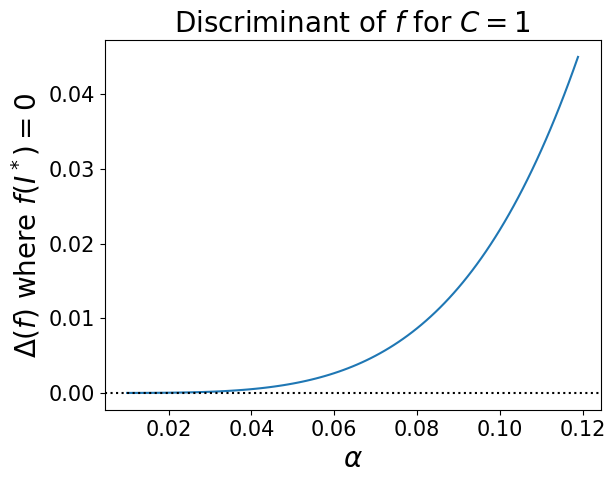

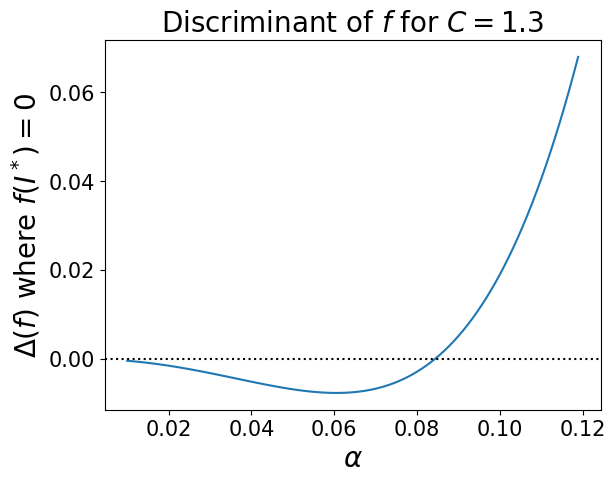

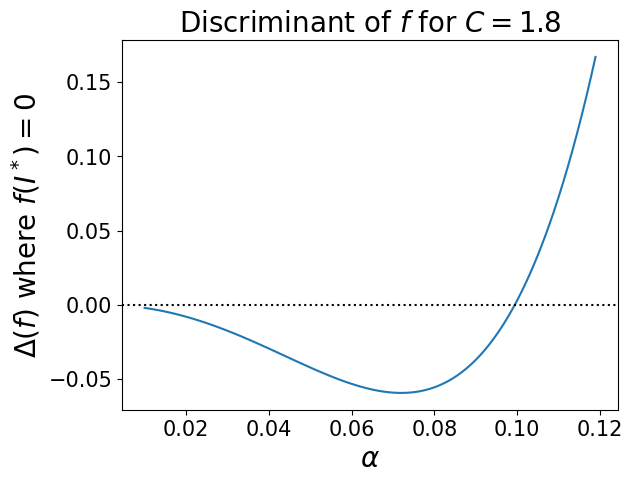

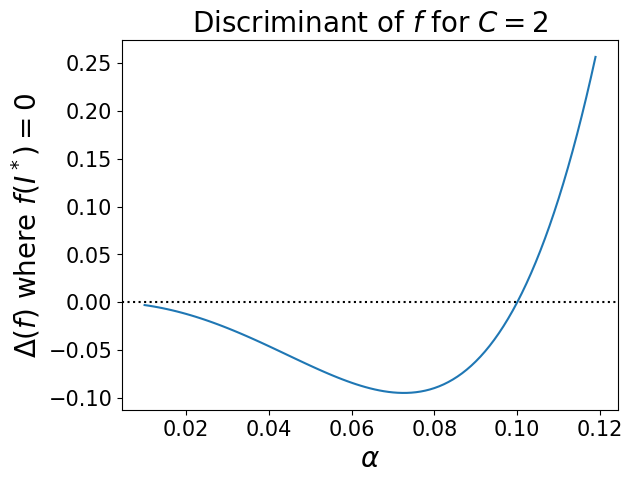

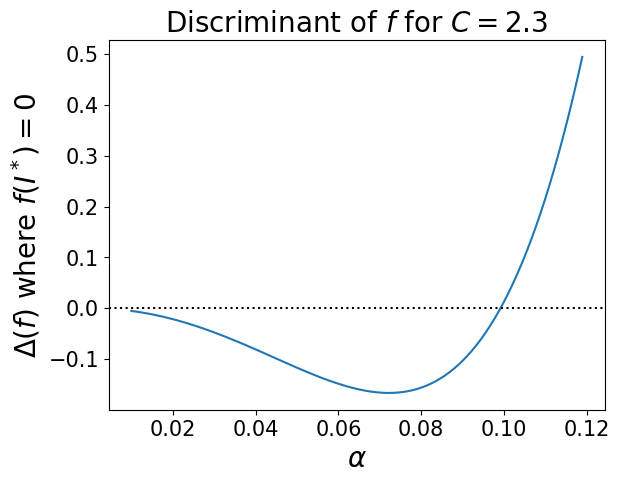

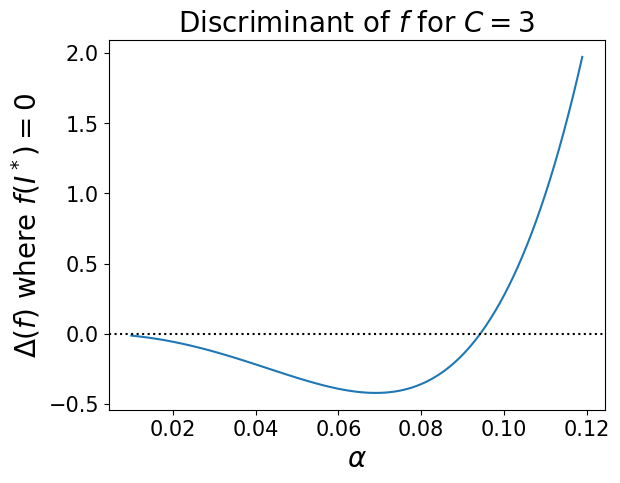

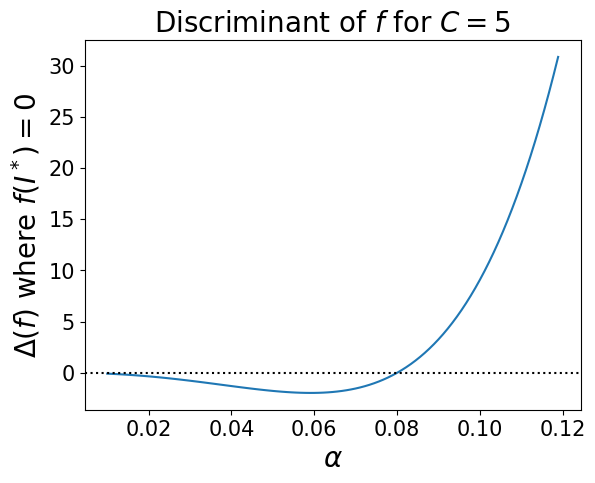

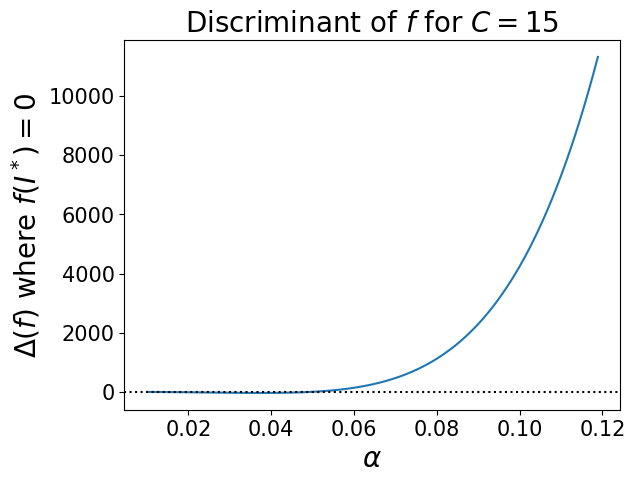

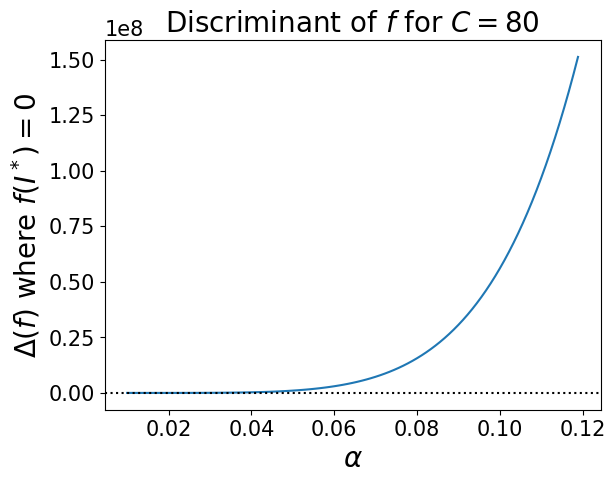

In [219]:
cut = -1
alpha = np.linspace(.01,.12,100)

for C in [1,1.3,1.8,2,2.3,3,5,15,80]:
    plt.plot(alpha[:cut], Discriminant(alpha[:cut], C=C), label=fr'$C=${C}')
    plt.axhline(y=0, ls=':', c='k')
    plt.title(fr'Discriminant of $f$ for $C=${C}')
    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$\Delta(f)$ where $f(I^*)=0$')
    #plt.legend()
    plt.show()

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_39844\1667928988.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left')


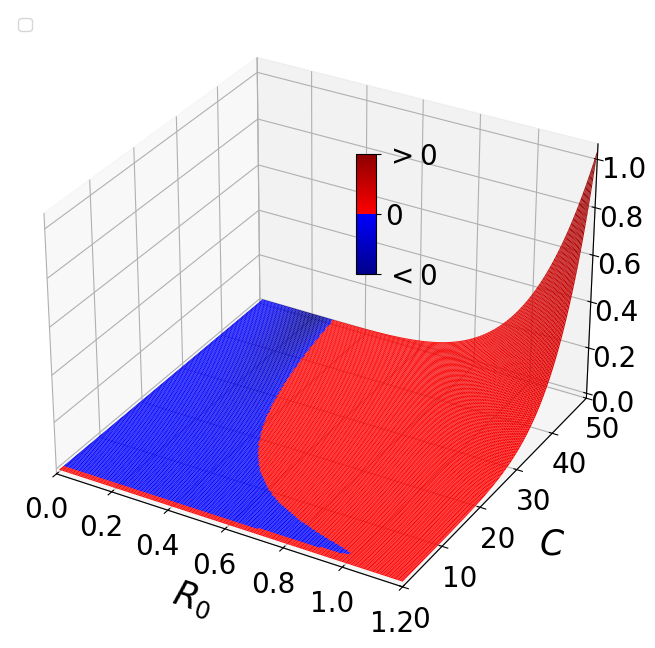

In [ ]:
alpha = np.linspace(.001,.12,200)
C = np.linspace(0.01,50,200) #np.logspace(-2,1.7,200)
alpha_mesh, C_mesh = np.meshgrid(alpha, C)

Discr_mesh = Discriminant(alpha_mesh, C_mesh)
Zero_mesh = np.zeros_like(Discr_mesh)

plt.rcParams['font.size'] = 25
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 30

fig = plt.figure(figsize=(10,8))

colors = [
    (0.0, "darkblue"), 
    (0.4999, "blue"),
    (0.5, "red"),
    (0.5001, "red"),
    (1.0, "darkred")
]

custom_cmap = LinearSegmentedColormap.from_list("sharp_jump", colors)


# # Create a GridSpec layout
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.03])  
# ax1 = fig.add_subplot(gs[0, 0], projection='3d')
# cbar_ax = fig.add_subplot(gs[0, 1]) 

# instead manually place colorbar
ax1 = fig.add_subplot(111, projection='3d')

norm = TwoSlopeNorm(vmin=np.min(Discr_mesh), vcenter=0, vmax=np.max(Discr_mesh))
surf1 = ax1.plot_surface(alpha_mesh, C_mesh, Discr_mesh, cmap=custom_cmap, norm=norm, rstride=1, cstride=1, antialiased=True, shade=False) # rstride=1 and cstride=1 forces the plot to include the entire resolution 
#surf0 = ax1.plot_surface(alpha_mesh, C_mesh, Zero_mesh, color='blue', label=r'$\Delta=0$')

#ax1.set_title(r'Roots of the Discriminant')
ax1.set_xlabel(r'$\alpha$', labelpad=15)
ax1.set_ylabel(r'$C$', labelpad=15)
ax1.set_zlabel(r'$\Delta(f)$', labelpad=15)
ax1.set_xlim(0,.12)
ax1.set_ylim(0,max(C))
ax1.legend(loc='upper left')

# Colorbar
cbar_ax = fig.add_axes([0.55, 0.55, 0.02, 0.15])  # [left bound, bottom bound, width, height]
cbar = fig.colorbar(surf1, cax=cbar_ax) #, label=r'Discriminant sign')
cbar.ax.tick_params(labelsize=20)
# Add negative ticks
# cbar.set_ticks([-950,-500, 0, 5e6, 10.5e6])  # Add -0.5 along with existing ticks
# cbar.set_ticklabels([-950,-500, 0, r'$5\cdot 10^{6}$',r'$10.5\cdot 10^{6}$'])  # Label the ticks
cbar.set_ticks([np.min(np.concatenate(Discr_mesh)), 0, np.max(np.concatenate(Discr_mesh))])  # Add -0.5 along with existing ticks
cbar.set_ticklabels([r'$<0$', 0, r'$>0$'])  # Label the ticks

ChangeXTicksFromAlphaToR0(ax=ax1)

#plt.tight_layout()
plt.savefig('img/SIRS_Discriminant_3DPlot_fordiffC_alpha.pdf', pad_inches=0.5, bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:64: RuntimeWarning: divide by zero encountered in divide
  c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:64: RuntimeWarning: invalid value encountered in multiply
  c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:65: RuntimeWarning: divide by zero encountered in divide
  d = (gamma/alpha-1)*nu*gamma*rho
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:66: RuntimeWarning: invalid value encountered in multiply
  return -27*a**2*d**2+18*a*b*c*d-4*a*c**3-4*b**3*d+b**2*c**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\277911569.py:21: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(alpha_mesh, C_mesh, Discr_mesh, levels=0, cmap=custom_cmap, label=r'$\Del

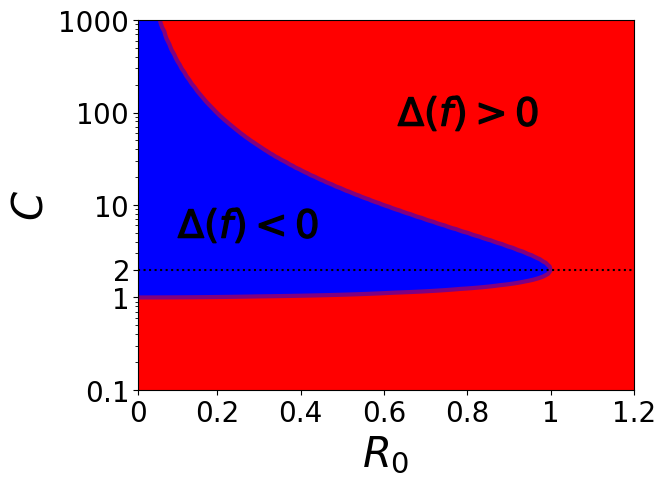

In [223]:
alpha = np.linspace(0,.12,100)
C = np.logspace(-1,3,100)
alpha_mesh, C_mesh = np.meshgrid(alpha, C)
Discr_mesh = Discriminant(alpha_mesh, C_mesh)

colors = [
    (0.0, "blue"), 
    (0.4999, "blue"),
    (0.5, "red"),
    (1.0, "red")
]

custom_cmap = LinearSegmentedColormap.from_list("sharp_jump", colors)

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 30

plt.contourf(alpha_mesh, C_mesh, Discr_mesh, levels=0, cmap=custom_cmap, label=r'$\Delta(f)$')
plt.contour(alpha_mesh, C_mesh, Discr_mesh, levels=[0], colors='purple', linewidths=3)
plt.axhline(y=2, ls=':', c='k', label=r'$C=2$')
#plt.fill_between(alpha, y1=2, y2=1, color='gray', alpha=.7, label=r'$C\in[1,2]$')

plt.scatter(0.08,100, marker=r'$\Delta(f)>0$', s=10000, c='k')
plt.scatter(0.027,6, marker=r'$\Delta(f)<0$', s=10000, c='k')
#plt.scatter(0.04,0.7, marker=r'$possible$ $Bifurcation$', s=15000, c='purple')#, rotation=45)

plt.xlabel(r'$R_0$')
plt.ylabel(r'$C$')
plt.yscale('log')
plt.yticks([0.1, 1, 2, 10, 100, 1000], labels=[r'$0.1$', r'$1$', r'$2$', r'$10$', r'$100$',1000])
plt.xticks([.001, .02, .04, .06, .08, .1, .12], labels=['0', .2, .4, .6, .8, 1, 1.2])
# plt.title('Sign of the Discriminant')

#ChangeXTicksFromAlphaToR0()
plt.xlim(0.001,0.12)

#plt.legend()
plt.savefig('img/SIRS_DiscriminantSign.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

### Signs of Prefactors, Discriminant and Solutions (What can we learn from the Cubic equation)

 How many roots of the CubicEq are positive? The same amount as sign changes btw. $a$ and $b$ or $b$ and $c$ or $c$ and $d$!

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:64: RuntimeWarning: divide by zero encountered in divide
  c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:64: RuntimeWarning: invalid value encountered in multiply
  c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:65: RuntimeWarning: divide by zero encountered in divide
  d = (gamma/alpha-1)*nu*gamma*rho
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:66: RuntimeWarning: invalid value encountered in multiply
  return -27*a**2*d**2+18*a*b*c*d-4*a*c**3-4*b**3*d+b**2*c**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\3382824118.py:11: RuntimeWarning: divide by zero encountered in divide
  Cval_Of_b_root = (2*gamma+nu*rho**2)/alpha
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel

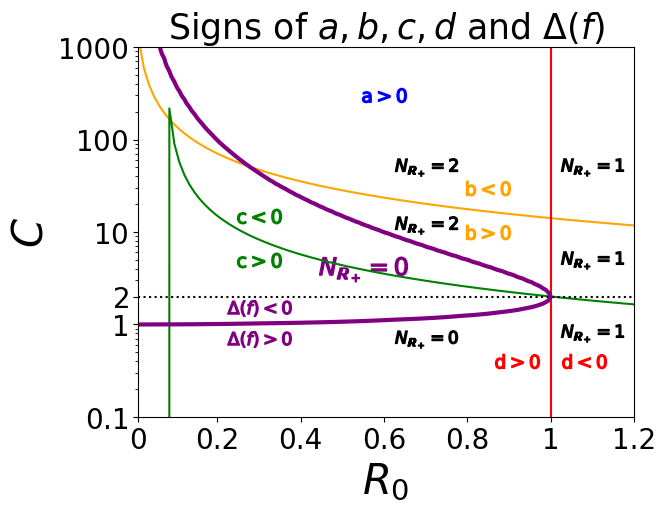

In [234]:
alpha = np.linspace(0,.12,100)
C = np.logspace(-1,3,100)
alpha_mesh, C_mesh = np.meshgrid(alpha, C)
Discr_mesh = Discriminant(alpha_mesh, C_mesh)

def RootsOfTheCbEqPrefactors(alpha, C, gamma=0.1, nu=0.01, RootOf = 'a'):
    rho = 1+gamma/nu
    if(RootOf == 'a'):
        return np.array([0,0])
    if(RootOf == 'b'):
        Cval_Of_b_root = (2*gamma+nu*rho**2)/alpha
        return np.array([alpha, Cval_Of_b_root])
    if(RootOf == 'c'):
        Cval_Of_c_root = 2*nu*gamma*rho**2/(-gamma**2/alpha+gamma+nu*rho**2)/alpha
        return np.array([alpha, Cval_Of_c_root])
    if(RootOf == 'd'):
        return np.array([np.full_like(C,gamma), C])

PreFactor = ['a', 'b', 'c', 'd']
COL = ['blue', 'orange', 'green', 'red']
alpha_coord = np.array([[False, 0.06], [0.085, 0.085], [0.03, 0.03], [0.108, 0.092]])  # coordinates for the markers
C_coord = np.array([[False, 300], [30, 10], [15, 5], [0.4, 0.4]])  # coordinates for the markers

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 25

plt.scatter(alpha_coord[0,1],C_coord[0,1], marker=fr'{PreFactor[0]}$>0$', s=1000, c=COL[0])
for i in [1,2,3]:
    plt.plot(RootsOfTheCbEqPrefactors(alpha, C, RootOf=PreFactor[i])[0], RootsOfTheCbEqPrefactors(alpha, C, RootOf=PreFactor[i])[1], c=COL[i]) #, label=fr'{PreFactor[i]} roots')
    plt.scatter(alpha_coord[i,0],C_coord[i,0], marker=fr'{PreFactor[i]}$<0$', s=1000, c=COL[i])
    plt.scatter(alpha_coord[i,1],C_coord[i,1], marker=fr'{PreFactor[i]}$>0$', s=1000, c=COL[i])
plt.axhline(y=2, ls=':', c='k', label=r'$C=2$')
plt.contour(alpha_mesh, C_mesh, Discr_mesh, levels=[0], colors='purple', linewidths=3, label=r'$\Delta(f)$ roots')

plt.scatter(0.055,4, marker=r'$N_{\mathbb{R}_+}=0$', s=4000, c='purple')
plt.scatter(0.03,0.7, marker=r'$\Delta(f)>0$', s=2100, c='purple')
plt.scatter(0.03,1.5, marker=r'$\Delta(f)<0$', s=2100, c='purple')

Size = 2000

plt.scatter(0.07,12, marker=r'$N_{\mathbb{R}_+}=2$', s=Size, c='black')
plt.scatter(0.07,50, marker=r'$N_{\mathbb{R}_+}=2$', s=Size, c='black')
plt.scatter(0.07,0.7, marker=r'$N_{\mathbb{R}_+}=0$', s=Size, c='black')

plt.scatter(0.11,5, marker=r'$N_{\mathbb{R}_+}=1$', s=Size, c='black')
plt.scatter(0.11,50, marker=r'$N_{\mathbb{R}_+}=1$', s=Size, c='black')
plt.scatter(0.11,0.8, marker=r'$N_{\mathbb{R}_+}=1$', s=Size, c='black')

plt.title(r'Signs of $a,b,c,d$ and $\Delta(f)$')
plt.yscale('log')
plt.xlabel(r'$R_0$')
plt.ylabel(r'$C$')
plt.yticks([0.1, 1, 2, 10, 100, 1000], labels=[r'$0.1$', r'$1$', r'$2$', r'$10$', r'$100$',1000])
plt.xticks([.001, .02, .04, .06, .08, .1, .12], labels=['0', .2, .4, .6, .8, 1, 1.2])
plt.ylim(0.1,1000)
#ChangeXTicksFromAlphaToR0()
plt.xlim(0.001,.12)

#plt.legend(loc='upper center')
plt.savefig('img/SIRS_SignsOfTheCbEqPrefactorsAndDiscriminant.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:64: RuntimeWarning: divide by zero encountered in divide
  c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:64: RuntimeWarning: invalid value encountered in multiply
  c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:65: RuntimeWarning: divide by zero encountered in divide
  d = (gamma/alpha-1)*nu*gamma*rho
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:66: RuntimeWarning: invalid value encountered in multiply
  return -27*a**2*d**2+18*a*b*c*d-4*a*c**3-4*b**3*d+b**2*c**2


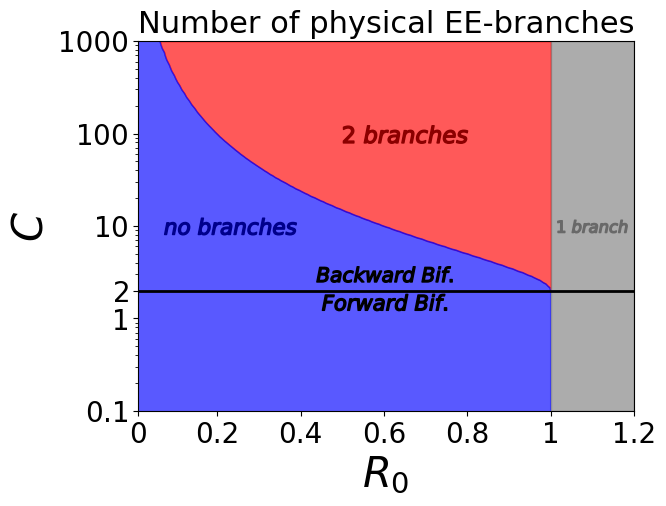

In [230]:
alpha = np.linspace(0,.12,100)
C = np.logspace(-1,3,100)
alpha_mesh, C_mesh = np.meshgrid(alpha, C)
Discr_mesh = Discriminant(alpha_mesh, C_mesh)

fig, ax = plt.subplots()
Discr_roots = plt.contour(alpha_mesh, C_mesh, Discr_mesh, levels=[0])#, colors='purple', linewidths=3, label=r'$\Delta(f)$ roots')
plt.close(fig) # Dont display the contour plot

Upper_Discr_roots = np.array([Point for Point in Discr_roots.allsegs[0][0] if Point[1]>=2-0.1]) # -0.1 for visualization purposes

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 22

plt.fill_betweenx(Upper_Discr_roots[:,1],Upper_Discr_roots[:,0], 0.1, color='red', alpha=0.65)
plt.fill_between(np.concatenate([[0],Upper_Discr_roots[:,0]]), 0,np.concatenate([[np.max(C)],Upper_Discr_roots[:,1]]), color='blue', alpha=0.65)
plt.fill_betweenx(C, 0.1, 0.12, color='gray', alpha=0.65)

plt.axhline(y=2, ls='-', c='k', lw=2)
plt.scatter(0.06,1.5, marker=r'$Forward$ $Bif.$', s=8000, c='k')
plt.scatter(0.06,3, marker=r'$Backward$ $Bif.$', s=9500, c='k')

plt.scatter(0.023,10, marker=r'$no$ $branches$', s=9000, c='darkblue')
plt.scatter(0.065,100, marker=r'$2$ $branches$', s=8000, c='darkred')
plt.scatter(0.11,10, marker=r'$1$ $branch$', s=2500, c='dimgrey')

plt.title(r'Number of physical EE-branches')
plt.yscale('log')
plt.xlabel(r'$R_0$')
plt.ylabel(r'$C$')
plt.yticks([0.1, 1, 2, 10, 100, 1000], labels=[r'$0.1$', r'$1$', r'$2$', r'$10$', r'$100$',1000])
plt.xticks([.001, .02, .04, .06, .08, .1, .12], labels=['0', .2, .4, .6, .8, 1, 1.2])
plt.ylim(0.1,1000)
#ChangeXTicksFromAlphaToR0()
plt.xlim(0.001,.12)

plt.savefig('img/SIRS_NumberOfpositiveEEBranches_AndFrwBckwBifurcation.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

### The physical (positive) Fixpoints (Fsolve Method <font color = 'red'> WORKED)

C:\Users\PCUser\AppData\Local\Temp\ipykernel_30620\1081503267.py:54: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15).item()
C:\Users\PCUser\AppData\Local\Temp\ipykernel_30620\1081503267.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15).item()
C:\Users\PCUser\AppData\Local\Temp\ipykernel_30620\1081503267.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15).item()


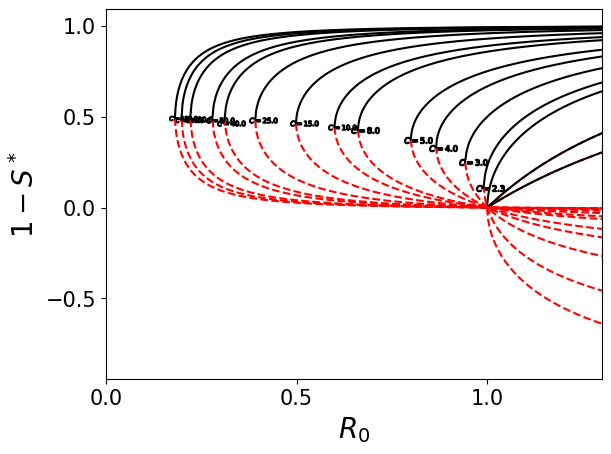

In [24]:
# Save Equilibria with fsolve Method

alpha = np.linspace(.01,0.19,1000)
C_array = np.array([0.5,1,2,2.3,3,4,5,8,10,15,25,40,50,80,100,120])

for idx in range(len(C_array)):
    Rinf_lower = 1-S_star_ana(alpha, C_array[idx], x0=0)
    Rinf_upper = 1-S_star_ana(alpha, C_array[idx], x0=0.5)
    
    Bif_Idx = GetBifIdxOfEE(Rinf_upper, Rinf_lower)

    Rinf_unstEq = Rinf_lower[Bif_Idx:]
    Rinf_endEq = Rinf_upper[Bif_Idx:]
    alpha_EE = alpha[Bif_Idx:]

    if(C_array[idx] == 2.3 or C_array[idx] == 0.5): C_toSave = C_array[idx] # to save integers as integers and floats as floats in the .npy filename
    else: C_toSave = int(C_array[idx])

    np.save(f'Data/DataSIRS_EE_analytical_C={C_toSave}.npy', [alpha_EE, Rinf_unstEq, Rinf_endEq])

    # save also Ainf for C=15 to plot 3D later
    if(C_array[idx]==15):
        Ainf_lower = A_star_ana(alpha, C=C_array[idx], x0=0)
        Ainf_upper = A_star_ana(alpha, C=C_array[idx], x0=0.5)
        Ainf_unstEq = Ainf_lower[Bif_Idx:]
        Ainf_endEq = Ainf_upper[Bif_Idx:]
        np.save(f'Data/DataSIRS_EE_analytical_Ainf_C={C_toSave}.npy', [alpha_EE, Ainf_unstEq, Ainf_endEq])

    plt.plot(alpha_EE, Rinf_unstEq, ls='--', c='r')
    plt.plot(alpha_EE, Rinf_endEq, ls='-', c='k')
    if(C_array[idx]>2): plt.scatter(alpha_EE[0]+0.002,Rinf_endEq[0],c='k',marker=rf'$C=${C_array[idx]}',s=400)
    else: plt.scatter(alpha_EE[-1]-0.005,Rinf_endEq[-1]-0.05,c='k',marker=rf'$C=${C_array[idx]}',s=400)

plt.xlabel(r'$\alpha$')
plt.ylabel(r'$1-S^*$')
ChangeXTicksFromAlphaToR0()
plt.xlim(0,.13)
plt.show()

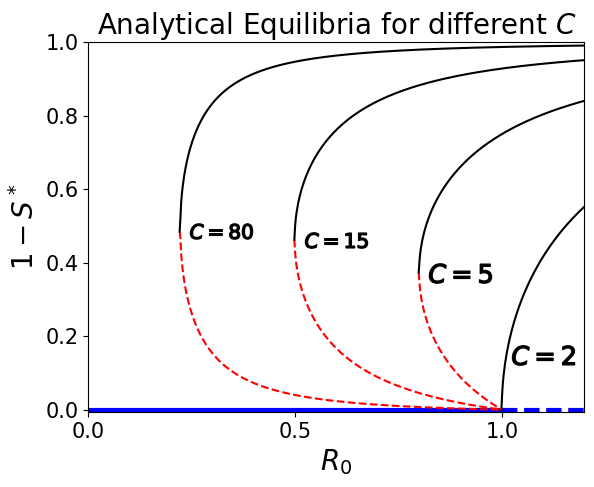

In [ ]:
# Plot Equilibria

alpha = np.linspace(.01,0.12,1000)
C_array = np.array([2,5,15,80])

PlotDFE()

for idx in range(len(C_array)):
    alpha_EE, Rinf_unstEq, Rinf_endEq = np.load(f'Data/DataSIRS_EE_analytical_C={C_array[idx]}.npy')
    R_0Is1_Idx = np.argmin(np.abs(alpha_EE - p['gamma'])) # index where R_0=1
    plt.plot(alpha_EE[:R_0Is1_Idx], Rinf_unstEq[:R_0Is1_Idx], ls='--', c='r')
    plt.plot(alpha_EE, Rinf_endEq, ls='-', c='k')
    if(C_array[idx]>2): plt.scatter(alpha_EE[0]+0.01,Rinf_endEq[0],c='k',marker=rf'$C=${round(C_array[idx])}',s=2000)
    else: plt.scatter(alpha_EE[-1]-0.08,Rinf_endEq[-1]-0.7,c='k',marker=rf'$C=${round(C_array[idx])}',s=2000)

plt.ylim(-0.006,1)
plt.title('Analytical Equilibria for different $C$')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$1-S^*$')
ChangeXTicksFromAlphaToR0()
plt.xlim(0,0.12)
plt.savefig('img/SIRS_BifurcationPlot_1-S_Analytical.pdf', bbox_inches='tight')
plt.show()

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:19: RuntimeWarning: invalid value encountered in scalar multiply
  c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  d = (gamma/alpha-1)*nu*gamma*rho
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:26: RuntimeWarning: invalid value encountered in scalar divide
  d1 = -b**3/(27*a**3)+b*c/(6*a**2)-d/(2*a)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:27: RuntimeWarning: invalid value encountered in scalar divide
  d0 = c/(3*a)-b**2/(9*a**2)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_2

0.0 :   (np.float64(0.0), np.float64(0.0), np.float64(nan), np.float64(inf))
0.008571428571428572 :   (np.float64(0.2222448979591837), np.float64(0.6445102040816326), np.float64(0.23585714285714285), np.float64(0.11733333333333333))
0.017142857142857144 :   (np.float64(0.8889795918367348), np.float64(1.248612244897959), np.float64(0.17971428571428572), np.float64(0.05316666666666667))
0.025714285714285717 :   (np.float64(2.0002040816326536), np.float64(1.8123061224489796), np.float64(0.12357142857142855), np.float64(0.03177777777777778))
0.03428571428571429 :   (np.float64(3.5559183673469392), np.float64(2.3355918367346935), np.float64(0.06742857142857142), np.float64(0.021083333333333332))
0.04285714285714286 :   (np.float64(5.556122448979593), np.float64(2.818469387755102), np.float64(0.01128571428571426), np.float64(0.014666666666666672))
0.051428571428571435 :   (np.float64(8.000816326530614), np.float64(3.260938775510204), np.float64(-0.04485714285714287), np.float64(0.01038888888

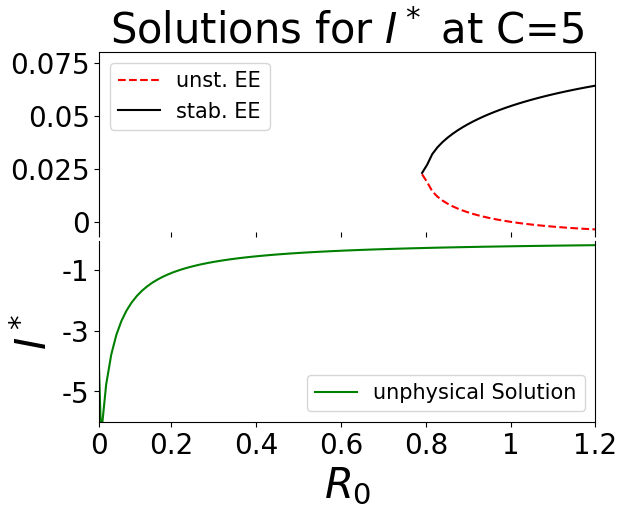

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)


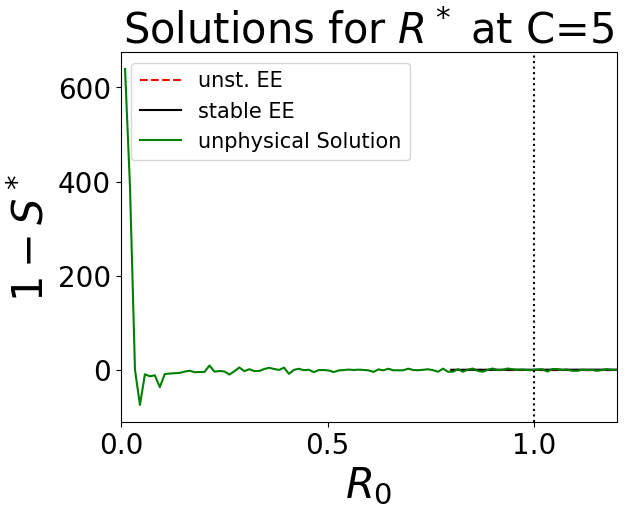

In [277]:
C_val = 5

for alpha in np.linspace(0,.12,15):
    print(alpha,":  ",CubicRootVarsForXstar(alpha, C=C_val)[:4])

alpha = np.linspace(0.001,.12,100)

Upper = X_star_ana_fsolved(alpha, C=C_val, x0=0.5)
Lower = X_star_ana_fsolved(alpha, C=C_val, x0=0)
Bif_Idx = GetBifIdxOfEE(Upper, Lower)

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 30

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 1]})

#PlotDFE()

ax1.plot(alpha[Bif_Idx:], Lower[Bif_Idx:], ls='--', c='r', label='unst. EE')
ax1.plot(alpha[Bif_Idx:], Upper[Bif_Idx:], ls='-', c='k', label='stab. EE')
ax1.set_ylim(-0.005, 0.08)
ax2.plot(alpha[Bif_Idx:], Lower[Bif_Idx:], ls='--', c='r')
ax2.plot(alpha, X_star_ana_fsolved(alpha, C=C_val, x0=-4), ls='-', c='g', label='unphysical Solution')
ax2.set_ylim(-6, -0.06)

#plt.axvline(x=p['gamma'], ls=':', c='k')#, label=r'$\gamma$')
#plt.axhline(y=0, ls=':', c='k')
ax1.set_title(rf'Solutions for $I^*$ at C={C_val}')
ax2.set_xlabel(r'$\alpha$')
ax1.set_yticks([0,0.025,0.05,0.075], labels=[0,0.025,0.05,0.075])
ax2.set_yticks([-1,-3,-5], labels=[-1,-3,-5])
plt.ylabel(r'$I^*$')
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labelbottom=False)
plt.subplots_adjust(hspace=0.05)

ChangeXTicksFromAlphaToR0(ax=ax2)
ax2.set_xticks([0.003,0.02,0.04,0.06,0.08,0.1,0.12], labels=['0',0.2,0.4,0.6,0.8,1,1.2])
for ax in [ax1, ax2]: ax.set_xlim(0.003,0.12) # unphyscal Line is wrong at small R0 (checked in cells below)
ax1.legend()
ax2.legend(loc='lower right')
plt.savefig('img/SIRS_ExampleOf_3Xinf-Sol_forC=5.pdf', bbox_inches='tight')
plt.show()

##############################################################
alpha_EE, Rinf_unstEq, Rinf_endEq = np.load(f'Data/DataSIRS_EE_analytical_C={C_val}.npy')

#PlotDFE()
plt.plot(alpha_EE, Rinf_unstEq, ls='--', c='r', label='unst. EE')
plt.plot(alpha_EE, Rinf_endEq, ls='-', c='k', label='stable EE')
plt.plot(alpha, 1-S_star_ana(alpha, C=C_val, x0=-4), ls='-', c='g', label='unphysical Solution')

plt.axvline(x=p['gamma'], ls=':', c='k')#, label=r'$\gamma$')
plt.title(rf'Solutions for $R^*$ at C={C_val}')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$1-S^*$')
ChangeXTicksFromAlphaToR0()
plt.xlim(0,0.12)

plt.legend()
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

<font color = 'red'> Just like predicted from the a,b,c,d root plot:

#### The EE branches in the other variables

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\App

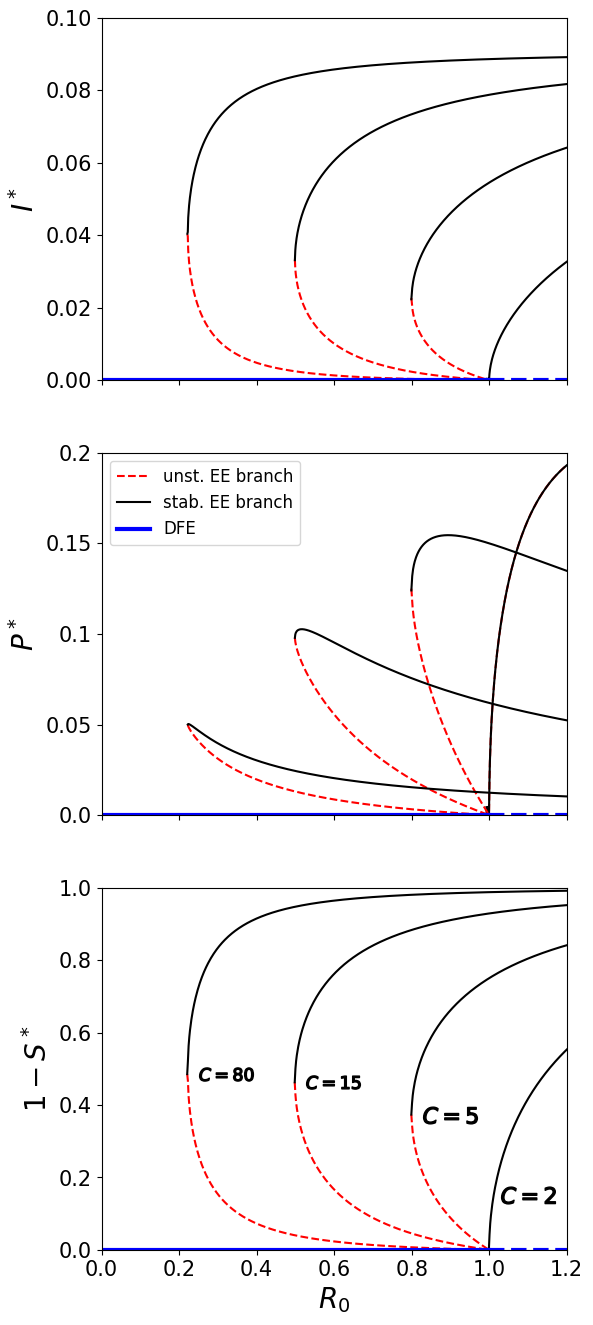

In [ ]:
alpha = np.linspace(.01,0.12,1000)
C_array = np.array([2, 5, 15, 80]) #np.array([0.5,1,2,2.3,3,4,5,15,40,80,100,120])

fig, axes = plt.subplots(3, 1, figsize=(6,16))

for idx in range(len(C_array)):
    # if(C_array[idx] != 1.1): continue

    X_upper = X_star_ana_fsolved(alpha, C_array[idx], x0=0.5)
    X_lower = X_star_ana_fsolved(alpha, C_array[idx], x0=0.01)
    Bif_Idx = GetBifIdxOfEE(X_upper, X_lower)
    X_unstEq = X_lower[Bif_Idx:]
    X_endEq = X_upper[Bif_Idx:]
    alpha_EE = alpha[Bif_Idx:]
    R_0Is1_Idx = np.argmin(np.abs(alpha_EE - p['gamma'])) # index where R_0=1
    axes[0].plot(alpha_EE[:R_0Is1_Idx], X_unstEq[:R_0Is1_Idx], ls='--', c='r')
    axes[0].plot(alpha_EE, X_endEq, ls='-', c='k')

    P_upper = P_star_ana(alpha, C_array[idx], x0=0.5)
    P_lower = P_star_ana(alpha, C_array[idx], x0=0.01)
    Bif_Idx = GetBifIdxOfEE(P_upper, P_lower)
    P_unstEq = P_lower[Bif_Idx:]
    P_endEq = P_upper[Bif_Idx:]
    alpha_EE = alpha[Bif_Idx:]
    axes[1].plot(alpha_EE, P_unstEq, ls='--', c='r', label='unst. EE branch' if idx==0 else None)
    axes[1].plot(alpha_EE, P_endEq, ls='-', c='k', label='stab. EE branch' if idx==0 else None)

    alpha_EE, Rinf_unstEq, Rinf_endEq = np.load(f'Data/DataSIRS_EE_analytical_C={C_array[idx]}.npy')
    R_0Is1_Idx = np.argmin(np.abs(alpha_EE - p['gamma'])) # index where R_0=1
    axes[2].plot(alpha_EE[:R_0Is1_Idx], Rinf_unstEq[:R_0Is1_Idx], ls='--', c='r')
    axes[2].plot(alpha_EE, Rinf_endEq, ls='-', c='k')
    if(C_array[idx]>2): axes[2].scatter(alpha_EE[0]+0.01,Rinf_endEq[0],c='k',marker=rf'$C=${round(C_array[idx])}',s=1500)
    else: axes[2].scatter(alpha_EE[-1]-0.08,Rinf_endEq[-1]-0.7,c='k',marker=rf'$C=${round(C_array[idx])}',s=1500)

    # if(C_array[idx]>2): plt.scatter(alpha[0]+0.002,Rinf_endEq[0],c='k',marker=rf'$C=${C_array[idx]}',s=400)
    # else: plt.scatter(alpha_EE[-1]-0.005,Rinf_endEq[-1]-0.05,c='k',marker=rf'$C=${C_array[idx]}',s=400)

# DFE
for ax in axes.flat:
    PlotDFE(ax=ax)

# Formatting
axes[0].tick_params(labelbottom=False)
axes[0].set_ylim(0,0.1)
axes[0].set_xlim(0, 0.12)
axes[0].set_ylabel(r'$I^*$')

axes[1].tick_params(labelbottom=False)
axes[1].set_ylim(0,0.2)
axes[1].set_xlim(0, 0.12)
axes[1].set_ylabel(r'$P^*$')
axes[1].set_yticks([0.00,0.05,0.10,0.15,0.20], labels=[0.00,0.05,0.10,0.15,0.20])
axes[1].legend(loc='upper left')

axes[2].set_ylim(0,1)
axes[2].set_xlim(0, 0.12)
axes[2].set_xlabel(r'$\alpha$')
axes[2].set_ylabel(r'$1-S^*$')
ChangeXTicksFromAlphaToR0(ax=axes[2])
plt.savefig('img/SIRS_BifurcationPlot_X_P_1-S_Analytical.pdf', bbox_inches='tight')
plt.show()

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\App

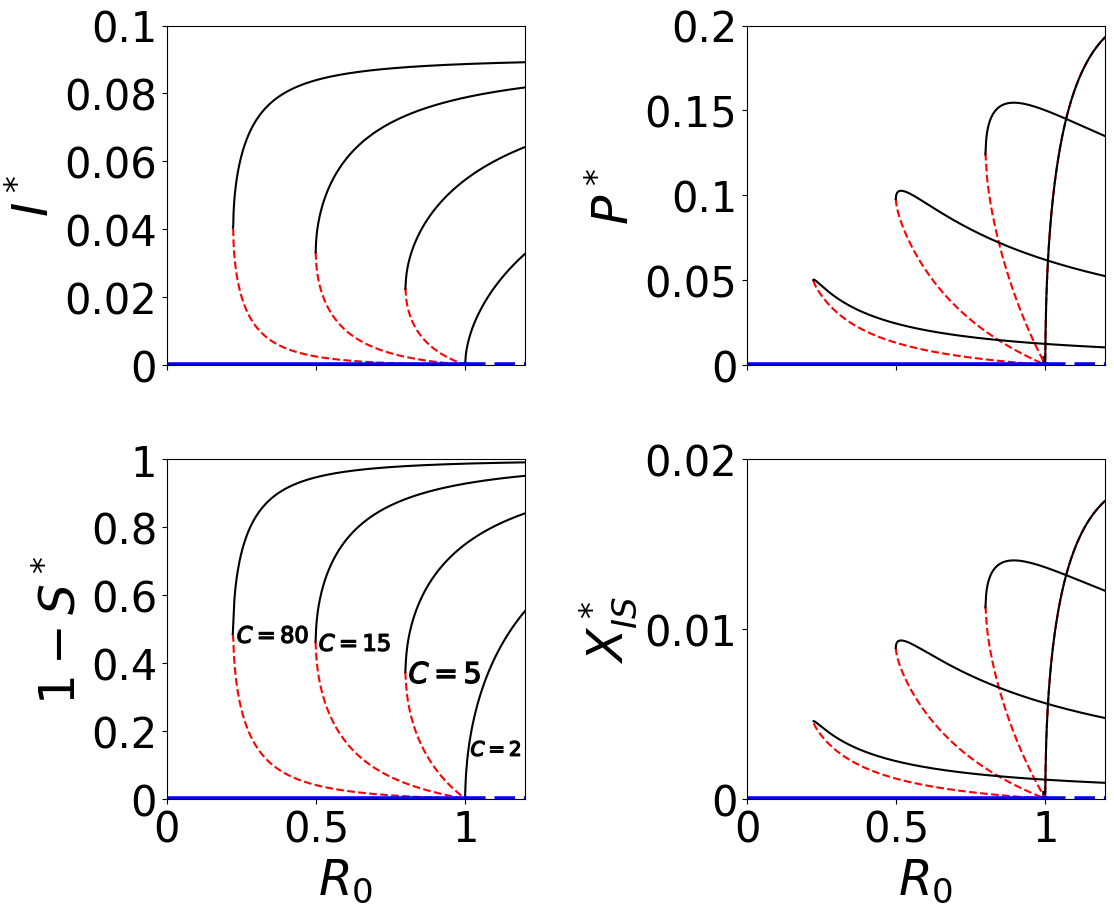

In [279]:
alpha = np.linspace(.01,0.12,1000)
C_array = np.array([2, 5, 15, 80]) #np.array([0.5,1,2,2.3,3,4,5,15,40,80,100,120])

shift = [0,1,5,205] # Idx shifts to correct EE branches of A*

plt.rcParams['font.size'] = 35
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['axes.titlesize'] = 35

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx in range(len(C_array)):
    # if(C_array[idx] != 1.1): continue

    # X^*
    X_upper = X_star_ana_fsolved(alpha, C_array[idx], x0=0.5)
    X_lower = X_star_ana_fsolved(alpha, C_array[idx], x0=0.01)
    Bif_Idx = GetBifIdxOfEE(X_upper, X_lower)
    X_unstEq = X_lower[Bif_Idx:]
    X_endEq = X_upper[Bif_Idx:]
    alpha_EE = alpha[Bif_Idx:]
    R_0Is1_Idx = np.argmin(np.abs(alpha_EE - p['gamma'])) # index where R_0=1
    axes[0, 0].plot(alpha_EE[:R_0Is1_Idx], X_unstEq[:R_0Is1_Idx], ls='--', c='r')
    axes[0, 0].plot(alpha_EE, X_endEq, ls='-', c='k')

    # P^*
    P_upper = P_star_ana(alpha, C_array[idx], x0=0.5)
    P_lower = P_star_ana(alpha, C_array[idx], x0=0.01)
    Bif_Idx = GetBifIdxOfEE(P_upper, P_lower)
    P_unstEq = P_lower[Bif_Idx:]
    P_endEq = P_upper[Bif_Idx:]
    alpha_EE = alpha[Bif_Idx:]
    axes[0, 1].plot(alpha_EE, P_unstEq, ls='--', c='r', label='unst. EE' if idx==0 else None)
    axes[0, 1].plot(alpha_EE, P_endEq, ls='-', c='k', label='stab. EE' if idx==0 else None)

    # 1-S^*
    alpha_EE, Rinf_unstEq, Rinf_endEq = np.load(f'Data/DataSIRS_EE_analytical_C={C_array[idx]}.npy')
    R_0Is1_Idx = np.argmin(np.abs(alpha_EE - p['gamma']))
    axes[1, 0].plot(alpha_EE[:R_0Is1_Idx], Rinf_unstEq[:R_0Is1_Idx], ls='--', c='r')
    axes[1, 0].plot(alpha_EE, Rinf_endEq, ls='-', c='k')
    if(C_array[idx]>2):
        axes[1, 0].scatter(alpha_EE[0]+0.013, Rinf_endEq[0], c='k', marker=rf'$C=${round(C_array[idx])}', s=2500)
    else:
        axes[1, 0].scatter(alpha_EE[-1]-0.08, Rinf_endEq[-1]-0.7, c='k', marker=rf'$C=${round(C_array[idx])}', s=1200)

    # A^*
    A_upper = A_star_ana(alpha, C_array[idx], x0=0.5)
    A_lower = A_star_ana(alpha, C_array[idx], x0=0.01)
    Bif_Idx = GetBifIdxOfEE(A_upper, A_lower)
    A_unstEq = A_lower[Bif_Idx-shift[idx]:]
    A_endEq = A_upper[Bif_Idx-shift[idx]:]
    alpha_EE = alpha[Bif_Idx-shift[idx]:]
    axes[1, 1].plot(alpha_EE, A_unstEq, ls='--', c='r', label='unst. EE' if idx==0 else None)
    axes[1, 1].plot(alpha_EE, A_endEq, ls='-', c='k', label='stab. EE' if idx==0 else None)

# DFE
for ax in axes.flat:
    PlotDFE(ax=ax, lw=4)

# Formatting
axes[0, 0].set_ylabel(r'$I^*$')
axes[0, 0].set_ylim(0, 0.1)
axes[0, 0].set_xlim(0, 0.12)
axes[0, 0].set_yticks([0,0.02,0.04,.06,.08,.1],labels=[0,0.02,0.04,.06,.08,.1])
axes[0, 0].tick_params(labelbottom=False)

axes[0, 1].set_ylabel(r'$P^*$')
axes[0, 1].set_ylim(0, 0.2)
axes[0, 1].set_xlim(0, 0.12)
axes[0, 1].set_yticks([0.00,0.05,0.10,0.15,0.20], labels=[0,0.05,0.10,0.15,0.20])
#axes[0, 1].legend(loc='upper left')
axes[0, 1].tick_params(labelbottom=False)

axes[1, 0].set_ylabel(r'$1-S^*$')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_xlabel(r'$\alpha$')
axes[1, 0].set_yticks([0,0.2,0.4,.6,.8,1],labels=[0,0.2,0.4,.6,.8,1])
ChangeXTicksFromAlphaToR0(ax=axes[1, 0], resetToxlims=True)
axes[1, 0].set_xlim(0, 0.12) # needs to be after ChangeXTicks for this plot... God knows why...

axes[1, 1].set_ylabel(r'$X_{IS}^*$')
axes[1, 1].set_ylim(0, 0.02)
axes[1, 1].set_xlim(0, 0.12)
axes[1, 1].set_yticks([0,0.01,0.02], labels=[0,0.01,0.02])
axes[1, 1].set_xlabel(r'$\alpha$')
ChangeXTicksFromAlphaToR0(ax=axes[1, 1], resetToxlims=True)

for i in range(2): 
    for j in range(2): axes[i,j].set_xticks([0,.05,.1],labels=[0,.5,1])

plt.tight_layout()
plt.savefig('img/SIRS_BifurcationPlot_A_X_P_1-S_Analytical.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykerne

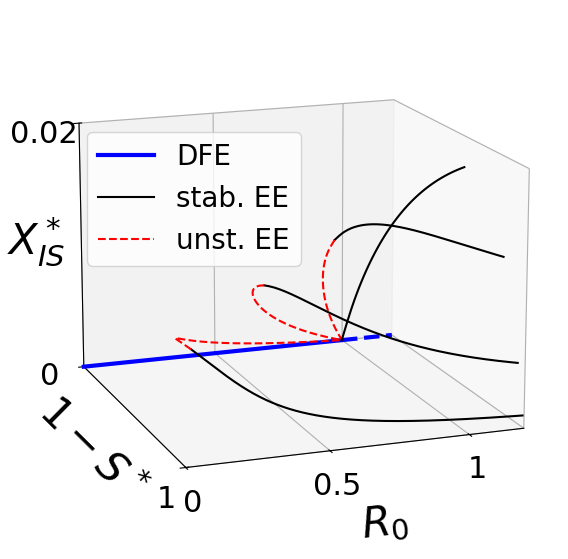

In [ ]:
alpha = np.linspace(.01,0.12,1000)
C_array = np.array([2, 5, 15, 80]) #np.array([0.5,1,2,2.3,3,4,5,15,40,80,100,120])

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 22
plt.rcParams['ytick.labelsize'] = 22
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['axes.titlesize'] = 30

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

#DFE
ax.plot([0,.1], [0,0], [0,0], linewidth = 3, ls='-', c='b', label='DFE')
ax.plot([.1,.12], [0,0], [0,0], linewidth = 3, ls='--', c='b')

for idx, C_val in reversed(list(enumerate(C_array))):
    alpha_EE, Rinf_unstEq, Rinf_endEq = np.load(f'Data/DataSIRS_EE_analytical_C={C_val}.npy')
    mask = alpha_EE<=max(alpha)
    alpha_EE, Rinf_unstEq, Rinf_endEq = alpha_EE[mask], Rinf_unstEq[mask], Rinf_endEq[mask]

    A_unstEq = A_star_ana(alpha_EE, C_val, x0=0.01)
    A_endEq = A_star_ana(alpha_EE, C_val, x0=0.5)
    ax.plot(alpha_EE, Rinf_endEq, A_endEq, color='k', label=f'stab. EE' if idx==0 else None)
    R_0Is1_Idx = np.argmin(np.abs(alpha_EE - p['gamma']))
    ax.plot(alpha_EE[:R_0Is1_Idx], Rinf_unstEq[:R_0Is1_Idx], A_unstEq[:R_0Is1_Idx], ls='--', color='r', label=f'unst. EE' if idx==0 else None)

ax.set_xlabel(r'$\alpha$', labelpad=20)
ax.set_ylabel(r'$1-S^*$')
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r'$X_{IS}^*$', labelpad=1)
ax.set_xlim(0, 0.12)
ax.set_ylim(0, 1)
ax.set_zlim(0, 0.02)
ax.set_yticks([1], labels=[1]) # ([0,1], labels=[0,1])
ax.set_zticks([0,0.02], labels=[0,0.02])
ax.zaxis.set_tick_params(pad=9)
ax.invert_xaxis()
ax.view_init(elev=15, azim=70) # view point
ChangeXTicksFromAlphaToR0(ax=ax)
ax.set_xticks([0,.05,.1], labels=[0,.5,1])
ax.legend(loc='upper left', bbox_to_anchor=(0.1, 0, 1,.8))
# plt.tight_layout()
plt.savefig('img/SIRS_3DBifurcationPlot_A_Rinf_alpha_Analytical.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

##### Plot Cross-section Dynamics at Alpha Slice

In [ ]:
### Plot cross-section at alpha=0.08 ###
alpha_slice = 0.055
alpha = np.linspace(.01, 0.12, 1000)
C_val = 15
########################################

# Load equilibrium data
alpha_EE, Rinf_unstEq, Rinf_endEq = np.load(f'Data/DataSIRS_EE_analytical_C={C_val}.npy')
mask = alpha_EE<=max(alpha)
alpha_EE, Rinf_unstEq, Rinf_endEq = alpha_EE[mask], Rinf_unstEq[mask], Rinf_endEq[mask]

X_unstEq = X_star_ana_fsolved(alpha_EE, C_val, x0=0.01)
X_endEq = X_star_ana_fsolved(alpha_EE, C_val, x0=0.5)
P_unstEq = P_star_ana(alpha_EE, C_val, x0=0.01)
P_endEq = P_star_ana(alpha_EE, C_val, x0=0.5)
Q_unstEq = Q_star_ana(alpha_EE, C_val, x0=0.01)
Q_endEq = Q_star_ana(alpha_EE, C_val, x0=0.5)
A_unstEq = A_star_ana(alpha_EE, C_val, x0=0.01)
A_endEq = A_star_ana(alpha_EE, C_val, x0=0.5)
AB_unstEq = AB_star_ana(alpha_EE, C_val, x0=0.01)
AB_endEq = AB_star_ana(alpha_EE, C_val, x0=0.5)

if alpha_slice > alpha_EE[0] and alpha_slice < alpha_EE[-1]:
    idx_slice = np.argmin(np.abs(alpha_EE - alpha_slice))
else: raise ValueError("alpha_slice out of bounds")

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)


C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1399511523.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


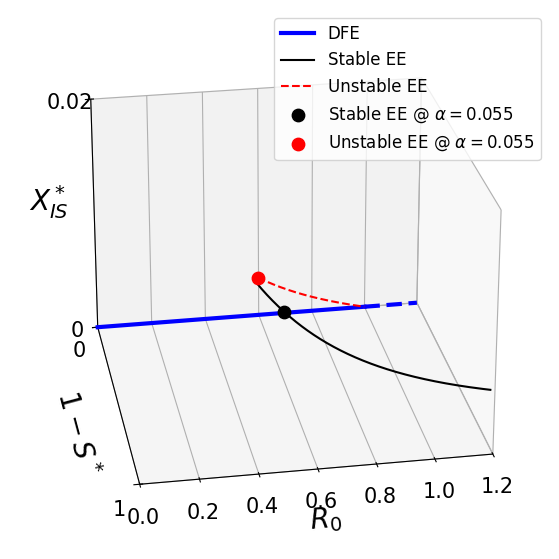

In [ ]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# DFE
ax.plot([0,.1], [0,0], [0,0], linewidth=3, ls='-', c='b', label='DFE')
ax.plot([.1,.12], [0,0], [0,0], linewidth=3, ls='--', c='b')

ax.plot(alpha_EE, Rinf_endEq, A_endEq, color='k', label=f'Stable EE')
R_0Is1_Idx = np.argmin(np.abs(alpha_EE - p['gamma']))
ax.plot(alpha_EE[:R_0Is1_Idx], Rinf_unstEq[:R_0Is1_Idx], A_unstEq[:R_0Is1_Idx], ls='--', color='r', label=f'Unstable EE')


if(alpha_slice > alpha_EE[0] and alpha_slice < alpha_EE[-1]):
    idx_slice = np.argmin(np.abs(alpha_EE - alpha_slice))
    ax.scatter(alpha_EE[idx_slice], Rinf_endEq[idx_slice], A_endEq[idx_slice], color='k', s=80, label=rf'Stable EE @ $\alpha=${alpha_slice}', zorder=10)
    ax.scatter(alpha_EE[idx_slice], Rinf_unstEq[idx_slice], A_unstEq[idx_slice], color='r', s=80, label=rf'Unstable EE @ $\alpha=${alpha_slice}', zorder=10)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$1-S^*$')
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r'$X_{IS}^*$')
ax.set_xlim(0, 0.12)
ax.set_ylim(0, 1)
ax.set_zlim(0, 0.02)
ax.set_yticks([0,1], labels=[0,1])
ax.set_zticks([0,0.02], labels=[0,0.02])
ax.invert_xaxis()
ax.view_init(elev=25, azim=80) # view point
ChangeXTicksFromAlphaToR0(ax=ax)
ax.legend()
plt.tight_layout()
plt.savefig('img/SIRS_3DBifurcationPlot_A_Rinf_alpha_DynamicsAtC=15.pdf', bbox_inches='tight')
plt.show()

In [ ]:
def Flow(R,X,P,Q,A,AB, alpha, C, gamma=0.1, nu=0.01):
    beta = C*alpha
    S = 1-R
    return [2*alpha*X*S-2*nu*(P-A), # dot R = -dot S
            alpha*X*S+beta*X*P-gamma*X,
            alpha*X*S-beta*X*P+nu*(X-P+Q-2*AB),
            2*beta*X*A+2*gamma*(-2*AB+X-A)-2*nu*(Q-AB),
            alpha*X*S-beta*X*A-gamma*A+nu*(X-AB-A),
            2*beta*X*A-2*gamma*AB]

def Streamplot_R_X(ax, RLims, XLims, P_val, A_val, alpha_slice, C_val, gamma=0.1, nu=0.01):
    # Define grid
    R_grid = np.linspace(RLims[0], RLims[1], 100)
    X_grid = np.linspace(XLims[0], XLims[1], 100)
    R_mesh, X_mesh = np.meshgrid(R_grid, X_grid)
    # Vectorize Grad_R_X for broadcasting

    dR_mesh, dX_mesh = Flow(R_mesh,X_mesh,P_val,0,A_val,0, alpha_slice, C_val, gamma=gamma, nu=nu)[0], Flow(R_mesh,X_mesh,P_val,0,A_val,0, alpha_slice, C_val, gamma=gamma, nu=nu)[1]
    ax.streamplot(R_mesh, X_mesh, dR_mesh, dX_mesh, color='b', density=2, linewidth=1, arrowsize=1.5, zorder=1)
    
def Streamplot_R_A(ax, RLims, ALims, X_val, AB_val, alpha_slice, C_val, gamma=0.1, nu=0.01):
    # Define grid
    R_grid = np.linspace(RLims[0], RLims[1], 100)
    A_grid = np.linspace(ALims[0], ALims[1], 100)
    R_mesh, A_mesh = np.meshgrid(R_grid, A_grid)
    # Vectorize Grad_R_X for broadcasting

    dR_mesh, dA_mesh = Flow(R_mesh,X_val,0,0,A_mesh,AB_val, alpha_slice, C_val, gamma=gamma, nu=nu)[0], Flow(R_mesh,X_val,0,0,A_mesh,AB_val, alpha_slice, C_val, gamma=gamma, nu=nu)[4]
    ax.streamplot(R_mesh, A_mesh, dR_mesh, dA_mesh, color='b', density=2, linewidth=1, arrowsize=1.5, zorder=1)

def Streamplot_R_X_P(Q_val, A_val, AB_val, alpha_slice, C_val, gamma=0.1, nu=0.01):
    # Define grid
    R_grid = np.linspace(0, 1, 100)
    X_grid = np.linspace(0, 0.1, 100)
    P_grid = np.linspace(0, 0.2, 100)
    R_mesh, X_mesh, P_mesh = np.meshgrid(R_grid, X_grid, P_grid)

    # Vectorize Grad_R_X_P for broadcasting
    dR_mesh, dX_mesh, dP_mesh = Flow(R_mesh,X_mesh,P_mesh,Q_val,A_val,AB_val, alpha_slice, C_val, gamma=gamma, nu=nu)[0], Flow(R_mesh,X_mesh,P_mesh,Q_val,A_val,AB_val, alpha_slice, C_val, gamma=gamma, nu=nu)[1], Flow(R_mesh,X_mesh,P_mesh,Q_val,A_val,AB_val, alpha_slice, C_val, gamma=gamma, nu=nu)[2]

    # Quiver plot (downsample for clarity)
    step = 10  # adjust for density
    ax.quiver(
        R_mesh[::step, ::step, ::step],
        X_mesh[::step, ::step, ::step],
        P_mesh[::step, ::step, ::step],
        dR_mesh[::step, ::step, ::step],
        dX_mesh[::step, ::step, ::step],
        dP_mesh[::step, ::step, ::step],
        length=0.01, normalize=True, color='b', linewidth=0.8
    )        

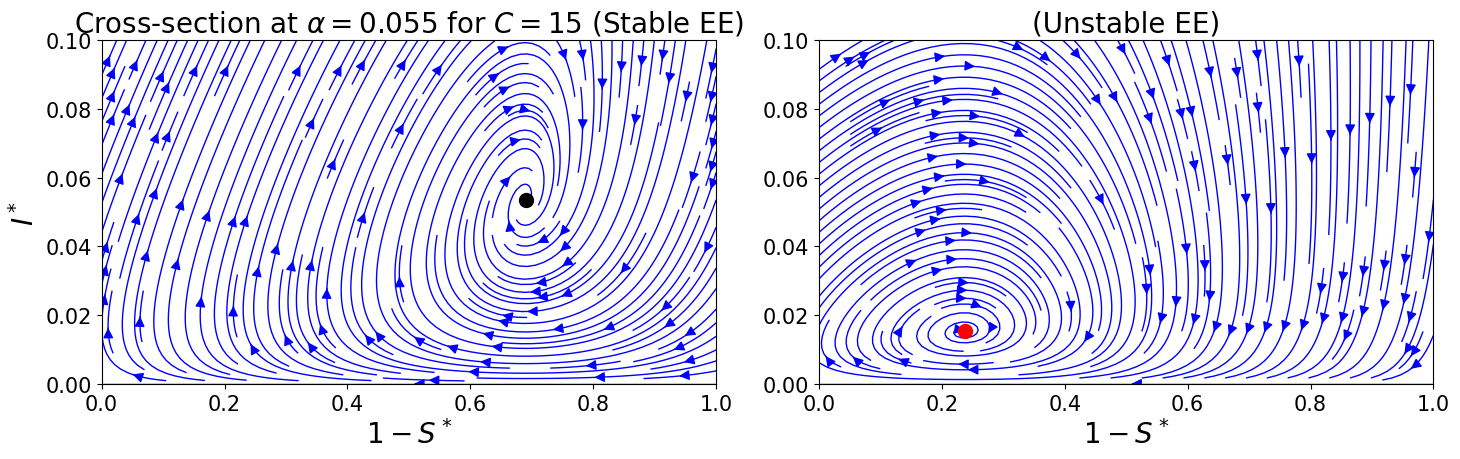

In [ ]:
# 2D plot: cross-section at alpha=0.08 for C=15, showing stable and unstable EE as dots

RLims = [0,1]
XLims = [0,0.1]

fig, ax = plt.subplots(1,2,figsize=(15,5))

# At stable EE
Streamplot_R_X(ax[0], RLims, XLims, P_val=P_endEq[idx_slice], A_val=A_endEq[idx_slice], alpha_slice=alpha_slice, C_val=C_val)
ax[0].scatter(Rinf_endEq[idx_slice], X_endEq[idx_slice], color='k', s=100, zorder=10, label='Stable EE')

# At unstable EE
Streamplot_R_X(ax[1], RLims, XLims, P_val=P_unstEq[idx_slice], A_val=A_unstEq[idx_slice], alpha_slice=alpha_slice, C_val=C_val)
ax[1].scatter(Rinf_unstEq[idx_slice], X_unstEq[idx_slice], color='r', s=100, zorder=10, label='Unstable EE')

# # Plot projection onto Rinf-A plane
# R_0Is1_Idx = np.argmin(np.abs(alpha_EE - p['gamma']))
# plt.plot(Rinf_endEq, A_endEq, color='k', label='Stable EE')
# plt.plot(Rinf_unstEq[:R_0Is1_Idx], A_unstEq[:R_0Is1_Idx], ls='--', color='r', label='Unstable EE')

ax[0].set_xlabel(r'$1-S^*$')
ax[1].set_xlabel(r'$1-S^*$')
ax[0].yaxis.set_rotate_label(False)
ax[0].set_ylabel(r'$I^*$')
ax[0].set_xlim(RLims[0], RLims[1])
ax[1].set_xlim(RLims[0], RLims[1])
ax[0].set_ylim(XLims[0], XLims[1])
ax[1].set_ylim(XLims[0], XLims[1])
ax[0].set_title(rf'Cross-section at $\alpha=${alpha_slice} for $C=15$ (Stable EE)')
ax[1].set_title(rf'(Unstable EE)')
plt.tight_layout()
plt.show()

## Stability of the Fixpoints

### Numerical EV-Calc <font color = 'red'>(WORKED)

In [13]:
def Jac_SIRS(SXPA_Vars_val, alpha_val, C, gamma=0.1, nu=0.01):

    alpha = alpha_val
    S,X,P,A = SXPA_Vars_val
    beta = alpha * C

    J = np.array([
        [-2*alpha*X, -2*alpha*S, 2*nu, 0, -2*nu, 0],
        [alpha*X, alpha*S + beta*P - gamma, beta*X, 0, 0, 0],
        [alpha*X, alpha*S - beta*P + nu, -beta*X - nu, nu, 0, -2*nu],
        [0, 2*beta*A + 2*gamma, 0, -2*nu, 2*beta*X - 2*gamma, -4*gamma + 2*nu],
        [alpha*X, alpha*S - beta*A + nu, 0, 0, -beta*X - gamma - nu, -nu],
        [0, 2*beta*A, 0, 0, 2*beta*X, -2*gamma]
    ])

    return J

def Jac_SIRS_linapprox(alpha_val, C, gamma=0.1, nu=0.01):

    alpha = alpha_val
    beta = alpha * C

    J = np.array([
        [0, 0, 2*nu, 0, -2*nu, 0],
        [0, - gamma, 0, 0, 0, 0],
        [0 , nu, - nu, nu, 0, -2*nu],
        [0, 2*gamma, 0, -2*nu, - 2*gamma, -4*gamma + 2*nu],
        [0, nu, 0, 0, - gamma - nu, -nu],
        [0, 0, 0, 0, 0, -2*gamma]
    ])

    return J

def JacEVs_SIRS(SXPA_Vars, alpha, C=5, gamma=0.1, nu=0.01, linapprox=False):
    EVs = np.zeros((len(alpha),6))

    S,X,P,A = SXPA_Vars

    for i in range(len(alpha)):
        SXPA_Vars_val = np.array([S[i], X[i], P[i], A[i]])
        if linapprox:
            EVs[i,:] = np.linalg.eigvals(Jac_SIRS_linapprox(alpha[i], C, gamma, nu))
        else:
            EVs[i,:] = np.linalg.eigvals(Jac_SIRS(SXPA_Vars_val, alpha[i], C, gamma, nu))
    return EVs

def Plot_Rinf_and_maxrealPartofJacEVs(alpha, C=5, gamma=0.1, nu=0.01, x_0 = [0.6,0.001]):

    print('Jacobian Eigenvalues for C=', C)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    LAB = ['upper EE', 'lower EE', 'DFE']

    for k in range(3): # stable EE, unstable EE, DFE

        if(k!=2):
            x0 = x_0[k]
            S = S_star_ana(alpha, C, gamma, nu, x0=x0, Method='fsolve')
            P = P_star_ana(alpha, C, gamma, nu, x0=x0, Method='fsolve')
            X = X_star_ana_fsolved(alpha, C, gamma, nu, x0=x0)
            A = A_star_ana(alpha, C, gamma, nu, x0=x0, Method='fsolve')
            
        else: S,P,X,A = np.ones_like(alpha), np.zeros_like(alpha), np.zeros_like(alpha), np.zeros_like(alpha) # DFE

        SXPA_Vars = np.array([S, X, P, A])

        axes[1,k].plot(alpha, np.max(JacEVs_SIRS(SXPA_Vars, alpha, C, gamma, nu)[:, :].real, axis=1), c='k')
        if(k==1): axes[1,k].set_title('Highest real part of the Jacobian-EVs')
        if(k!=0): axes[1,k].tick_params(labelleft=False)
        axes[1,k].set_ylim(0, 0.01)
        #axes[1,k].legend()

        axes[0,k].set_title(LAB[k])
        axes[0,k].plot(alpha, P, ls='-', c='b', label=r'$P$',lw = 3)# if k==2 else 1)
        axes[0,k].plot(alpha, X, ls='-', c='g', label=r'$I$',lw = 3)# if k==2 else 1)
        axes[0,k].plot(alpha, A, ls='-', c='yellow', label=r'$X_{IS}$',lw = 3)# if k==2 else 1)
        axes[0,k].plot(alpha, 1-S, ls='-', c='k', label=r'$1-S$',lw = 3)# if k==2 else 1)
        axes[0,k].set_ylim(-0.02, 1)
        axes[0,k].set_xlim(.02,.12)
        axes[0,k].set_xlabel(r'$\alpha$')
        if(k==0): axes[0,k].legend()
        else: axes[0,k].tick_params(labelleft=False)

        # Not working: Its dividing by gamma/2 instead of gamma
        ChangeXTicksFromAlphaToR0(axes[0,k], resetToxlims=True) 
        ChangeXTicksFromAlphaToR0(axes[1,k], resetToxlims=True)

    plt.tight_layout()

<font color = 'red'> For $\alpha>\gamma$ aka $R_0>1$ the lower EE branch becomes stable because it drops below the DFE (below 0)

Jacobian Eigenvalues for C= 1


C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykerne

Jacobian Eigenvalues for C= 2


C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\App

Jacobian Eigenvalues for C= 5


C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\App

Jacobian Eigenvalues for C= 15


C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykerne

Jacobian Eigenvalues for C= 80


C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Te

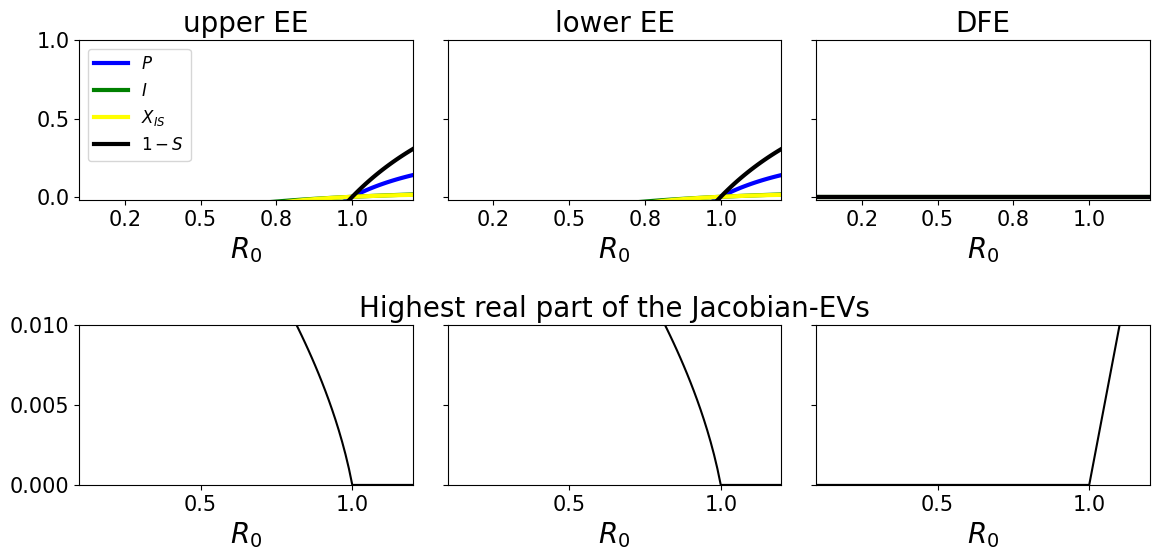

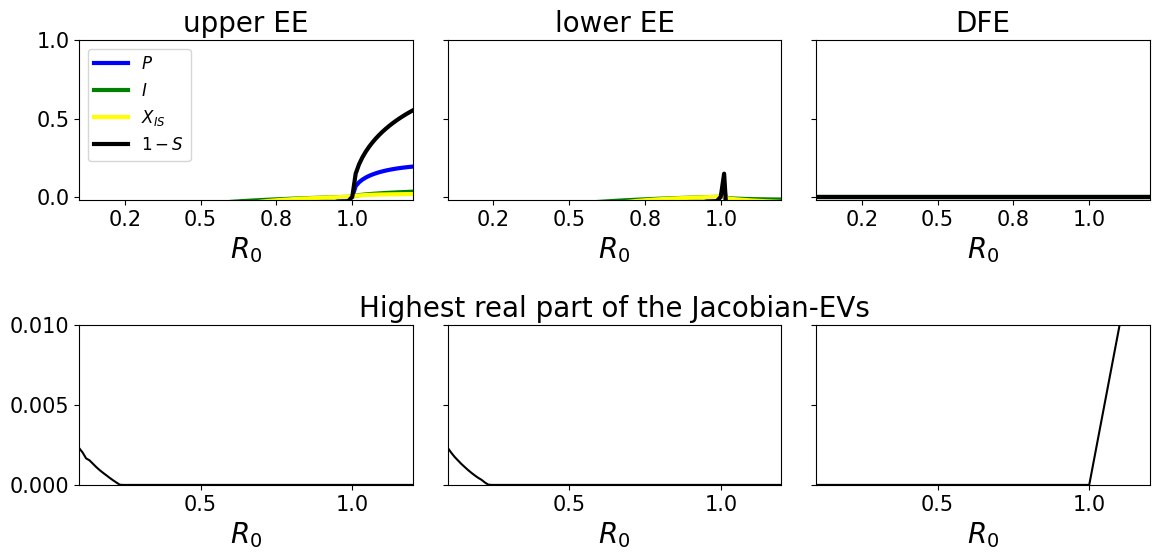

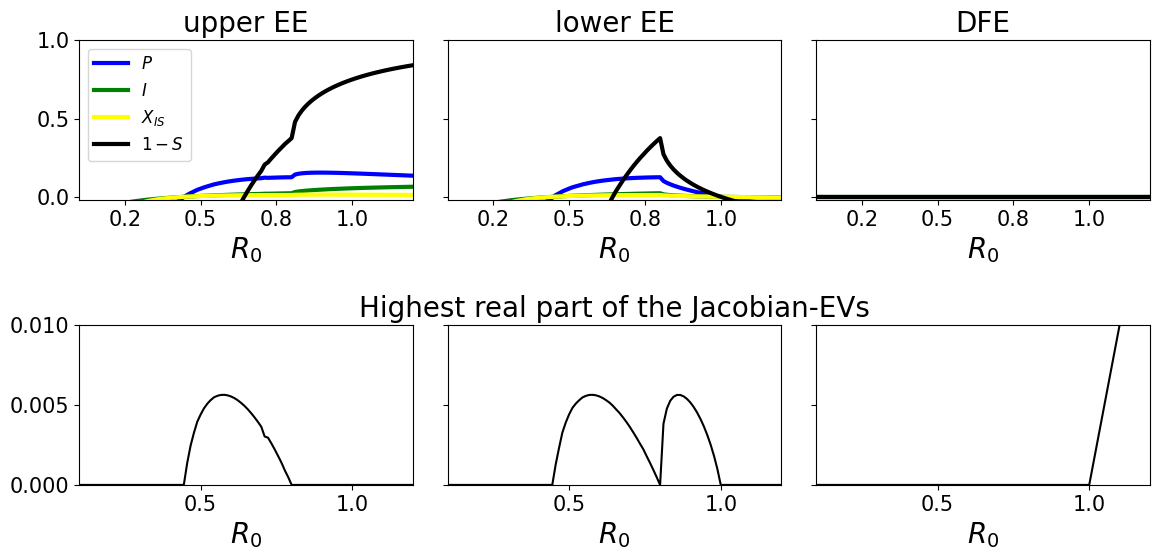

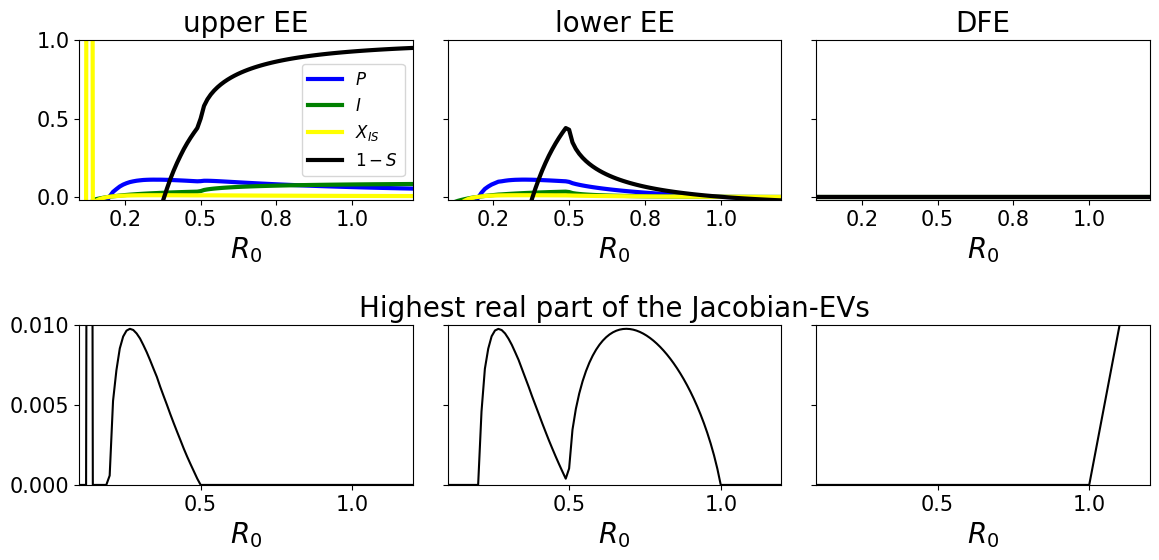

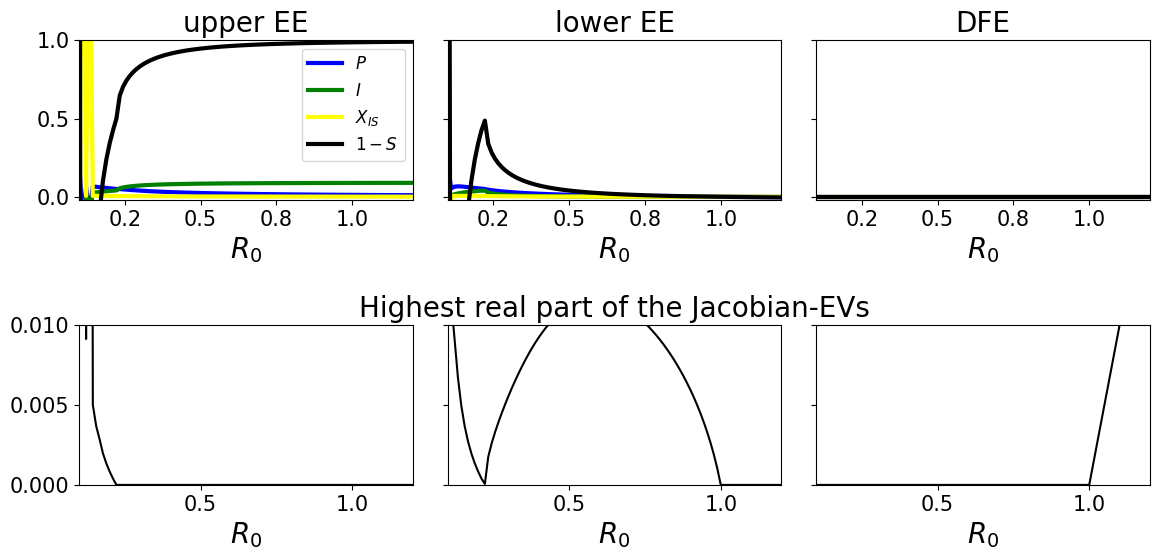

In [ ]:
alpha = np.linspace(.01,.12,100)

for C in [1,2,5,15,80]:
    Plot_Rinf_and_maxrealPartofJacEVs(alpha, C, gamma=0.1, nu=0.01, x_0 = [0.6,0.001,-5])
    if(C==15 or C==5): plt.savefig(f'img/SIRS_JacEVs_C={C}.pdf', bbox_inches='tight')

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_20248\1036197408.py:54: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykerne

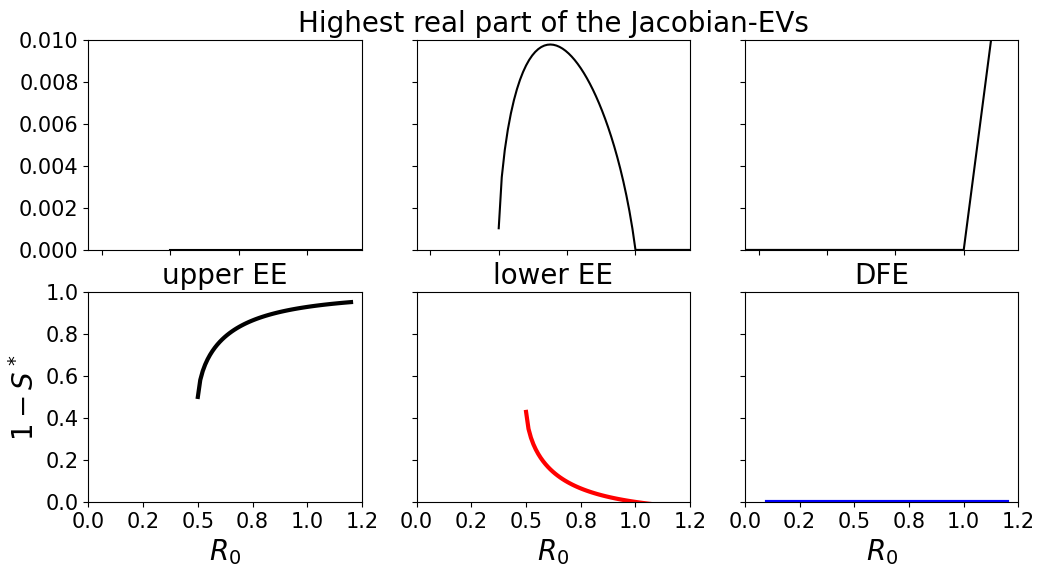

In [ ]:
C = 15
x_0 = [0.6,0.001,-5]
COL = ['k','r','b']
alpha = np.linspace(.01,.12,100)
#####

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
LAB = ['upper EE', 'lower EE', 'DFE']

for k in range(3): # stable EE, unstable EE, DFE
    
    if(k==2): Mask = np.ones_like(alpha, dtype=bool) # dont change anything
    else:
        R0_bif_atC15 = 0.04988876515698579 # calculated in LC_seasonalityORmitigation_Figure notebook
        Mask = alpha>R0_bif_atC15 # cut the complex solutions of the model that occur at R_0<R_0^bif (below creation of EE branches)

    if(k!=2):
        x0 = x_0[k]
        S = S_star_ana(alpha, C, gamma=0.1, nu=0.01, x0=x0, Method='fsolve')
        P = P_star_ana(alpha, C, gamma=0.1, nu=0.01, x0=x0, Method='fsolve')
        X = X_star_ana_fsolved(alpha, C, gamma=0.1, nu=0.01, x0=x0)
        A = A_star_ana(alpha, C, gamma=0.1, nu=0.01, x0=x0, Method='fsolve')
        
    else: S,P,X,A = np.ones_like(alpha), np.zeros_like(alpha), np.zeros_like(alpha), np.zeros_like(alpha) # DFE

    SXPA_Vars = np.array([S, X, P, A])

    axes[0,k].plot(alpha[Mask], np.max(JacEVs_SIRS(SXPA_Vars, alpha, C, gamma=0.1, nu=0.01)[:, :].real, axis=1)[Mask], c='k')
    if(k==1): axes[0,k].set_title('Highest real part of the Jacobian-EVs')
    if(k!=0): axes[0,k].tick_params(labelleft=False)
    axes[0,k].set_ylim(0, 0.01)
    axes[0,k].tick_params(labelbottom=False)
    #axes[0,k].legend()

    axes[1,k].set_title(LAB[k])
    axes[1,k].plot(alpha[Mask], 1-S[Mask], ls='-', c=COL[k], label=r'$1-S$',lw = 3)# if k==2 else 1)
    axes[1,k].set_ylim(0, 1)
    axes[1,k].set_xlabel(r'$\alpha$')
    if(k==0): axes[1,k].set_ylabel(r'$1-S^*$')
    else: axes[1,k].tick_params(labelleft=False)

    axes[1,k].set_xlim(.02,.12)
    axes[0,k].set_xlim(.02,.12)

    # Not working: Its dividing by gamma/2 instead of gamma
    ChangeXTicksFromAlphaToR0(axes[1,k], resetToxlims=False)

    plt.savefig(f'img/SIRS_JacEVs_EXAMPLE.pdf', bbox_inches='tight')

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28384\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28384\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28384\1036197408.py:54: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykerne

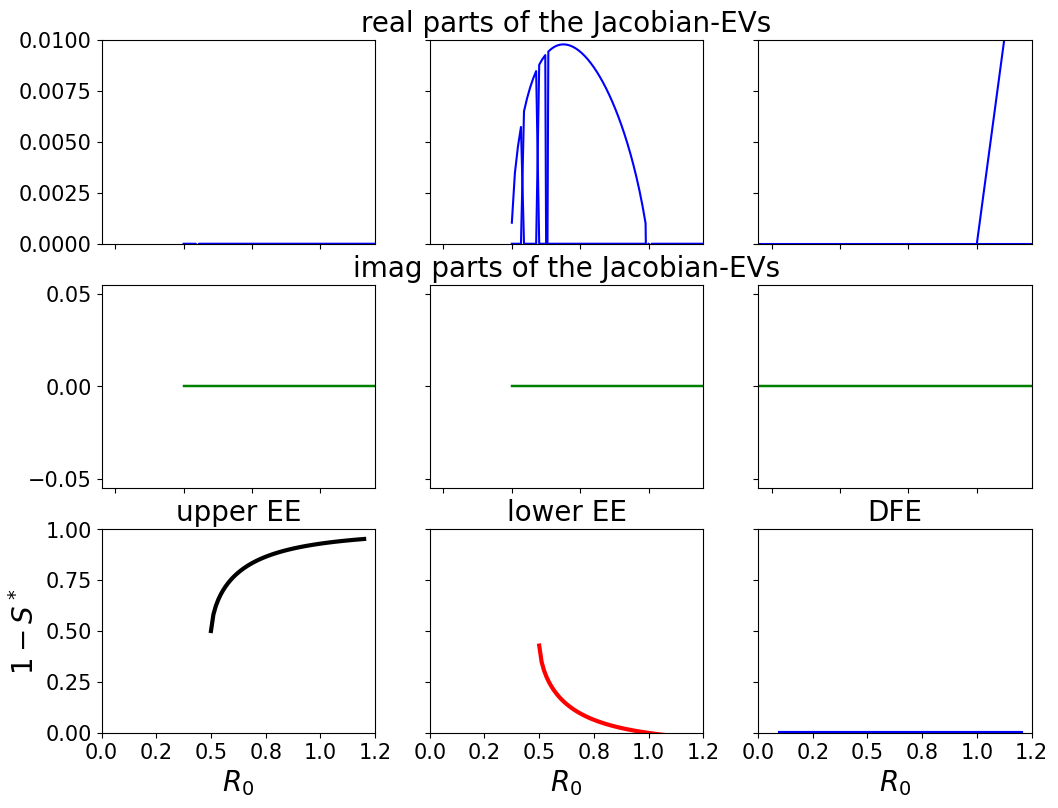

In [16]:
C = 15
x_0 = [0.6,0.001,-5]
COL = ['k','r','b']
alpha = np.linspace(.01,.12,100)
#####

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
LAB = ['upper EE', 'lower EE', 'DFE']

for k in range(3): # stable EE, unstable EE, DFE
    
    if(k==2): Mask = np.ones_like(alpha, dtype=bool) # dont change anything
    else:
        R0_bif_atC15 = 0.04988876515698579 # calculated in LC_seasonalityORmitigation_Figure notebook
        Mask = alpha>R0_bif_atC15 # cut the complex solutions of the model that occur at R_0<R_0^bif (below creation of EE branches)

    if(k!=2):
        x0 = x_0[k]
        S = S_star_ana(alpha, C, gamma=0.1, nu=0.01, x0=x0, Method='fsolve')
        P = P_star_ana(alpha, C, gamma=0.1, nu=0.01, x0=x0, Method='fsolve')
        X = X_star_ana_fsolved(alpha, C, gamma=0.1, nu=0.01, x0=x0)
        A = A_star_ana(alpha, C, gamma=0.1, nu=0.01, x0=x0, Method='fsolve')
        
    else: S,P,X,A = np.ones_like(alpha), np.zeros_like(alpha), np.zeros_like(alpha), np.zeros_like(alpha) # DFE

    SXPA_Vars = np.array([S, X, P, A])

    axes[0,k].plot(alpha[Mask], JacEVs_SIRS(SXPA_Vars, alpha, C, gamma=0.1, nu=0.01)[Mask, :].real, c='b')
    if(k==1): axes[0,k].set_title('real parts of the Jacobian-EVs')
    if(k!=0): axes[0,k].tick_params(labelleft=False)
    axes[0,k].set_ylim(0, 0.01)
    axes[0,k].tick_params(labelbottom=False)
    #axes[0,k].legend()

    axes[1,k].plot(alpha[Mask], JacEVs_SIRS(SXPA_Vars, alpha, C, gamma=0.1, nu=0.01)[Mask, :].imag, c='g')
    if(k==1): axes[1,k].set_title('imag parts of the Jacobian-EVs')
    if(k!=0): axes[1,k].tick_params(labelleft=False)
    #axes[1,k].set_ylim(0, 0.01)
    axes[1,k].tick_params(labelbottom=False)
    #axes[1,k].legend()

    axes[2,k].set_title(LAB[k])
    axes[2,k].plot(alpha[Mask], 1-S[Mask], ls='-', c=COL[k], label=r'$1-S$',lw = 3)# if k==2 else 1)
    axes[2,k].set_ylim(0, 1)
    axes[2,k].set_xlabel(r'$\alpha$')
    if(k==0): axes[2,k].set_ylabel(r'$1-S^*$')
    else: axes[2,k].tick_params(labelleft=False)

    for i in range(3): axes[i,k].set_xlim(.02,.12)

    # Not working: Its dividing by gamma/2 instead of gamma
    ChangeXTicksFromAlphaToR0(axes[2,k], resetToxlims=False)

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28244\1036197408.py:54: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Res[i] = fsolve(CubicEqForXstar, x0, args=(alpha[i], C, gamma, nu), xtol=1e-15)
C:\Users\Rodrigo Amaral Lind\App

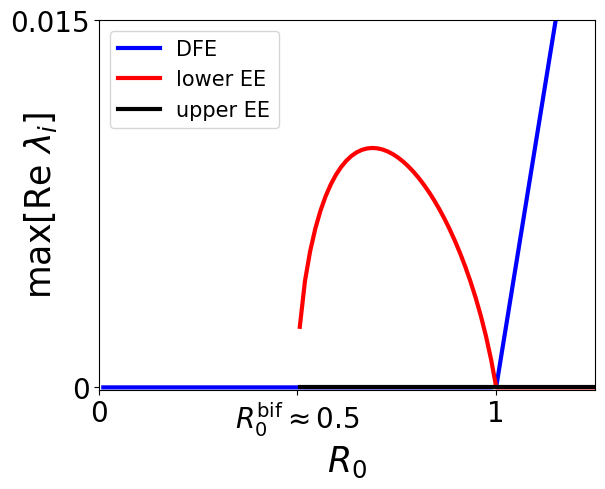

In [217]:
C = 15
x_0 = [0.6,0.001,-5]
COL = ['k','r','b']
alpha = np.linspace(.001,.13,100)

plt.rcParams['font.size'] = 25
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 20
#####

LAB = ['upper EE', 'lower EE', 'DFE']

for k in [2,1,0]: # stable EE, unstable EE, DFE
    
    if(k==2): Mask = np.ones_like(alpha, dtype=bool) # dont change anything
    else:
        R0_bif_atC15 = 0.04988876515698579 # calculated in LC_seasonalityORmitigation_Figure notebook
        Mask = alpha>R0_bif_atC15 # cut the complex solutions of the model that occur at R_0<R_0^bif (below creation of EE branches)

    if(k!=2):
        x0 = x_0[k]
        S = S_star_ana(alpha, C, gamma=0.1, nu=0.01, x0=x0, Method='fsolve')
        P = P_star_ana(alpha, C, gamma=0.1, nu=0.01, x0=x0, Method='fsolve')
        X = X_star_ana_fsolved(alpha, C, gamma=0.1, nu=0.01, x0=x0)
        A = A_star_ana(alpha, C, gamma=0.1, nu=0.01, x0=x0, Method='fsolve')
        
    else: S,P,X,A = np.ones_like(alpha), np.zeros_like(alpha), np.zeros_like(alpha), np.zeros_like(alpha) # DFE

    SXPA_Vars = np.array([S, X, P, A])

    plt.plot(alpha[Mask], np.max(JacEVs_SIRS(SXPA_Vars, alpha, C, gamma=0.1, nu=0.01)[:, :].real, axis=1)[Mask], c=COL[k], label=LAB[k], lw=3)

#plt.title('Highest real part of the Jacobian-EVs')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\max[{\rm Re}~\lambda_i]$', labelpad=-35)
plt.ylim(-0.0001, 0.015)
plt.xlim(0,.12)
plt.legend(loc='upper left')

ChangeXTicksFromAlphaToR0()

plt.yticks([0,0.015], labels=[0,0.015])
plt.xticks([0,R0_bif_atC15,0.1], labels=[0,r'$R_0^{\rm bif}\approx0.5$',1])

plt.savefig(f'img/SIRS_JacEVs_EXAMPLE_COMPACT.pdf', bbox_inches='tight')

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20